In [ ]:
# Injected parameters
WDN_NAME = 'Alperovits'
EXTRA_DEMAND = 1.2
MEASUREMENT_NODES = ['1']
INP_DIR = '/home/birkenma/Dokumente/INVERSE-PROBLEM/wdn/Alperovits.inp'
BASE_DIR = '/home/birkenma/Dokumente/INVERSE-PROBLEM/old/data/Alperovits/datasets/438c36873b0a3794181daa28e4f860ba2faa57c17181e9d7fc1f264bc82cb1ec'
NUM_SIMULATIONS = 5000


In [ ]:
WDN_NAME = 'Alperovits'
EXTRA_DEMAND = 1.2
MEASUREMENT_NODES = ['1']
INP_DIR = '/home/birkenma/Dokumente/INVERSE-PROBLEM/wdn/Alperovits.inp'
BASE_DIR = '/home/birkenma/Dokumente/INVERSE-PROBLEM/old/data/Alperovits/datasets/438c36873b0a3794181daa28e4f860ba2faa57c17181e9d7fc1f264bc82cb1ec'
CRITICAL_PATH_METHOD = True

In [ ]:
import numpy as np
import wntr
import torch
#from torch_geometric.data import Data
import pandas as pd
import networkx as nx  
import copy
import matplotlib.pyplot as plt
#######



In [10]:
wntr.__version__
# use wntr 1.2.0

'1.2.0'

In [ ]:
# Create a water network model
wn = wntr.network.WaterNetworkModel(INP_DIR)
wn_orig = copy.deepcopy(wn)
# Simulate hydraulics
sim = wntr.sim.EpanetSimulator(wn)
results = sim.run_sim()

# Alperovits ['7']
# anytown ['180']
# BAK ['36']
# Hanoi ['33]
# Baghmalek ['74']
# kadu ['27']
# modena ['289']
# zhijiang ['114']
## Extra demands

# Alperovits 1.2
# anytown 0.5
# BAK 1.2
# Hanoi 5.5
# Baghmalek 0.22
# kadu 0.3
# modena 0.4
# zhijiang 1.2

## Data generation flow
### one time
1. import base inp and create base wn
2. recognize secondary pipes
3. calculate base pressures for all nodes
### for each data set
4. calculate the critical path
5. select measurement points
6. simulate with changing base demand, reservoir head and pattern
7. add pressures to the measurement points features
8. add measurement points with weights to the networkx graph
9. add both directions for secondary pipes
9. save graphs

In [12]:
def get_reservoir_nodes(wn):
    """
    Retrieve a list of all node names that are of type Reservoir from the water network model.
    
    Args:
        wn (wntr.network.WaterNetworkModel): The water network model.
        
    Returns:
        list: A list of reservoir node names.
    """
    reservoir_nodes = [name for name, reservoir in wn.reservoirs()]
    return reservoir_nodes

In [13]:
def add_uniform_extra_demand(wn, extra_demand=1):
    """
    Add extra demand to junctions using a uniform probability distribution.
    The extra demand is distributed among junctions such that each junction has an equal
    chance of receiving any portion of the total extra demand.
    
    Args:
        wn (wntr.network.WaterNetworkModel): The water network model
        extra_demand (float): Total amount of extra demand to distribute (default: 1)
        
    Returns:
        tuple: (modified wn, demand_distribution)
            - modified wn: Water network with extra demand added
            - demand_distribution: Dictionary mapping junction names to their extra demand values
    """
    # Create a deep copy to avoid modifying the original network
    wn_copy = copy.deepcopy(wn)
    
    # Get all junctions
    junctions = [name for name, junction in wn_copy.junctions()]
    num_junctions = len(junctions)
    
    if num_junctions == 0:
        return wn_copy, {}
    
    # Generate uniform random numbers for each junction
    # We use Dirichlet distribution to ensure sum = 1
    # Alpha = 1 for uniform distribution
    alpha = np.ones(num_junctions)
    probabilities = np.random.dirichlet(alpha)
    
    # Create demand distribution dictionary
    demand_distribution = {}
    
    # Add extra demand to each junction based on probabilities
    for junction_name, prob in zip(junctions, probabilities):
        junction = wn_copy.get_node(junction_name)
        
        # Calculate extra demand for this junction
        junction_extra_demand = prob * extra_demand
        
        # Add to base demand if it exists
        if junction.demand_timeseries_list:
            current_base_demand = junction.demand_timeseries_list[0].base_value
            junction.demand_timeseries_list[0].base_value = current_base_demand + junction_extra_demand
        
        # Store the distribution
        demand_distribution[junction_name] = junction_extra_demand
    
    return wn_copy, demand_distribution

def verify_uniform_distribution(num_simulations=5000, num_junctions=5, extra_demand=100):
    """
    Verify that the extra demand distribution is uniform across junctions.
    
    Args:
        num_simulations (int): Number of simulations to run
        num_junctions (int): Number of junctions in the network
        extra_demand (float): Total extra demand to distribute
        
    Returns:
        dict: Statistics about the distribution
    """
    # Initialize counters for each junction
    junction_stats = {f'junction_{i}': {
        'total_extra_demand': 0,
        'min_extra_demand': float('inf'),
        'max_extra_demand': float('-inf'),
        'zero_count': 0
    } for i in range(num_junctions)}
    
    # Run multiple simulations
    for _ in range(num_simulations):
        # Generate uniform random numbers
        alpha = np.ones(num_junctions)
        probabilities = np.random.dirichlet(alpha)
        
        # Calculate extra demand for each junction
        for i, prob in enumerate(probabilities):
            junction_name = f'junction_{i}'
            junction_extra_demand = prob * extra_demand
            
            # Update statistics
            stats = junction_stats[junction_name]
            stats['total_extra_demand'] += junction_extra_demand
            stats['min_extra_demand'] = min(stats['min_extra_demand'], junction_extra_demand)
            stats['max_extra_demand'] = max(stats['max_extra_demand'], junction_extra_demand)
            if junction_extra_demand == 0:
                stats['zero_count'] += 1
    
    # Calculate averages and percentages
    for stats in junction_stats.values():
        stats['avg_extra_demand'] = stats['total_extra_demand'] / num_simulations
        stats['zero_percentage'] = (stats['zero_count'] / num_simulations) * 100
    
    return junction_stats

def generate_synthetic_dataset(wn, num_simulations=5000, extra_demand=100):
    """
    Generate a synthetic dataset by adding uniformly distributed extra demand
    to the water network.
    
    Args:
        wn (wntr.network.WaterNetworkModel): The water network model
        num_simulations (int): Number of simulations to run
        extra_demand (float): Total extra demand to distribute
        
    Returns:
        list: List of tuples containing (modified_wn, demand_distribution) for each simulation
    """
    dataset = []
    
    for i in range(num_simulations):
        modified_wn, demand_distribution = add_uniform_extra_demand(wn, extra_demand)
        dataset.append((modified_wn, demand_distribution))
        
        # Print progress every 10%
        if (i + 1) % (num_simulations // 10) == 0:
            print(f"Progress: {i + 1}/{num_simulations} simulations completed")
    
    return dataset

In [14]:
# Generate a single scenario
modified_wn, demand_dist = add_uniform_extra_demand(wn, extra_demand=100)

# Verify the distribution
stats = verify_uniform_distribution(num_simulations=100, num_junctions=5, extra_demand=100)

# Generate a complete dataset
dataset = generate_synthetic_dataset(wn, num_simulations=100, extra_demand=100)

Progress: 10/100 simulations completed
Progress: 20/100 simulations completed
Progress: 30/100 simulations completed
Progress: 40/100 simulations completed
Progress: 50/100 simulations completed
Progress: 60/100 simulations completed
Progress: 70/100 simulations completed
Progress: 80/100 simulations completed
Progress: 90/100 simulations completed
Progress: 100/100 simulations completed


In [15]:
def analyze_pressure_range(wn, n_simulations=1000, extra_demand=0.3):
    """
    Analyze the pressure range in the network by running multiple simulations.
    
    Args:
        wn (wntr.network.WaterNetworkModel): The water network model
        n_simulations (int): Number of simulations to run (default: 1000)
        extra_demand (float): Amount of extra demand to add (default: 0.03)
        
    Returns:
        tuple: (max_pressure, min_pressure)
    """
    max_p = 0
    min_p = float('inf')  # Initialize with infinity to ensure first value is always smaller
    
    for i in range(n_simulations):
        # Add extra demand and run simulation
        modified_wn, demand_dist = add_uniform_extra_demand(wn, extra_demand=extra_demand)
        
        # Run simulation
        sim = wntr.sim.EpanetSimulator(modified_wn)
        results = sim.run_sim()
        
        # Get pressure values (excluding reservoirs)
        pressures = results.node['pressure'].iloc[-1][:-1]  # Get last timestep #todo: change location of reservior
        current_max = pressures.max()
        current_min = pressures.min()
        
        # Update max and min
        max_p = max(max_p, current_max)
        min_p = min(min_p, current_min)
        
        # Print statistics for this simulation
        #print(f"Simulation {i+1}: Min={current_min:.2f}, Mean={pressures.mean():.2f}, Max={current_max:.2f}")
    
    return max_p, min_p


In [ ]:
max_p, min_p = analyze_pressure_range(wn, n_simulations=1000, extra_demand=EXTRA_DEMAND)
max_p = int(max_p*1.01)
min_p = int(min_p*0.99)
print(max_p, min_p)

58 41


In [17]:
def get_max_elevation(wn):
    """
    Find the minimum elevation in the water network, excluding reservoirs.
    
    Args:
        wn (wntr.network.WaterNetworkModel): The water network model
        
    Returns:
        float: Minimum elevation in the network
    """
    max_elevation = -float('inf')
    
    # Check elevations of all junctions
    for junction_name, junction in wn.junctions():
        elevation = junction.elevation
        if elevation is not None and elevation > max_elevation:
            max_elevation = elevation
    
    return max_elevation

def get_min_elevation(wn):
    """
    Find the minimum elevation in the water network, excluding reservoirs.
    
    Args:
        wn (wntr.network.WaterNetworkModel): The water network model
        
    Returns:
        float: Minimum elevation in the network
    """
    min_elevation = float('inf')
    
    # Check elevations of all junctions
    for junction_name, junction in wn.junctions():
        elevation = junction.elevation
        if elevation is not None and elevation < min_elevation:
            min_elevation = elevation
    
    return min_elevation

min_elv = get_min_elevation(wn)
print(min_elv)

150.0


In [18]:
def calculate_flow_direction(wn):
    """
    Calculate flow direction for each pipe in the water network.
    
    Args:
        wn (wntr.network.WaterNetworkModel): The water network model.
        
    Returns:
        dict: Dictionary mapping pipe names to their flow directions (1 for forward, -1 for reverse)
    """
    # Run hydraulic simulation
    sim = wntr.sim.EpanetSimulator(wn)
    results = sim.run_sim()
    
    # Get flow rates for all pipes
    flow_rates = results.link['flowrate'].iloc[-1]
    
    # Determine flow direction (1 for forward, -1 for reverse)
    flow_directions = {}
    for pipe_name, flow in flow_rates.items():
        flow_directions[pipe_name] = 1 if flow >= 0 else -1
    
    return flow_directions

def simulate_flow_direction_changes(wn, num_simulations=100, extra_demand=14, seed=None):
    """
    Simulate multiple scenarios with uniformly distributed extra demand and count
    flow direction changes in each pipe.

    Args:
        wn (wntr.network.WaterNetworkModel): The water network model.
        num_simulations (int): Number of simulations to run (default: 100).
        extra_demand (float): Total extra demand to distribute (default: 100).
        seed (int, optional): Random seed for reproducibility.

    Returns:
        tuple: (direction_change_count, flow_directions_history)
            - direction_change_count: dict with pipe names and their direction change counts
            - flow_directions_history: dict with pipe names and list of their flow directions
    """
    if seed is not None:
        np.random.seed(seed)

    # Calculate original flow directions
    original_flow_directions = calculate_flow_direction(wn)
    
    # Initialize dictionaries
    direction_change_count = {pipe_name: 0 for pipe_name in original_flow_directions.keys()}
    flow_directions_history = {pipe_name: [original_flow_directions[pipe_name]] 
                             for pipe_name in original_flow_directions.keys()}

    # Run simulations with modified demand patterns
    for i in range(num_simulations):
        try:
            # Create a deep copy of the water network
            wn_copy = copy.deepcopy(wn)

            # Add uniformly distributed extra demand
            modified_wn, _ = add_uniform_extra_demand(wn_copy, extra_demand)

            # Calculate new flow directions
            new_flow_directions = calculate_flow_direction(modified_wn)

            # Compare new directions with previous and count changes
            for pipe_name in original_flow_directions.keys():
                prev_direction = flow_directions_history[pipe_name][-1]
                curr_direction = new_flow_directions[pipe_name]
                
                # Store the new direction
                flow_directions_history[pipe_name].append(curr_direction)
                
                # Count direction change if it's different from previous
                if curr_direction != prev_direction:
                    direction_change_count[pipe_name] += 1

        except Exception as e:
            print(f"Warning: Simulation {i} failed with error: {str(e)}")
            print(f"Error type: {type(e)}")
            import traceback
            print(f"Traceback: {traceback.format_exc()}")
            continue

    return direction_change_count, flow_directions_history

def find_secondary_pipes(direction_change_count, num_simulations, threshold=0.2, min_changes=1):
    """
    Identify secondary pipes based on flow direction change frequency.
    
    Args:
        direction_change_count (dict): Dictionary of direction change counts for each pipe
        num_simulations (int): Total number of simulations run
        threshold (float): Minimum ratio of direction changes to consider a pipe secondary
        min_changes (int): Minimum number of direction changes required
        
    Returns:
        tuple: (secondary_pipes, change_ratios)
            - secondary_pipes: List of pipe names identified as secondary
            - change_ratios: Dictionary of change ratios for all pipes
    """
    secondary_pipes = []
    change_ratios = {}
    
    for pipe_name, changes in direction_change_count.items():
        ratio = changes / num_simulations
        change_ratios[pipe_name] = ratio
        
        if ratio >= threshold and changes >= min_changes:
            secondary_pipes.append(pipe_name)
    
    return secondary_pipes, change_ratios

In [ ]:
if not CRITICAL_PATH_METHOD:
    # Run simulations
    direction_change_count, flow_directions_history = simulate_flow_direction_changes(
        wn, 
        num_simulations=1000,
        extra_demand=EXTRA_DEMAND
    )

    # Find secondary pipes
    secondary_pipes, change_ratios = find_secondary_pipes(
        direction_change_count,
        num_simulations=1000,
        threshold=0.1
    )

    # Print results


    print("Secondary pipes:", secondary_pipes)
    print("Number of Secondary pipes:", len(secondary_pipes))
    print("\nChange ratios for all pipes:")
    for pipe, ratio in sorted(change_ratios.items(), key=lambda x: x[1], reverse=True):
        print(f"{pipe}: {ratio:.2%}")



Secondary pipes: ['4', '6']
Number of Secondary pipes: 2

Change ratios for all pipes:
6: 47.90%
4: 17.60%
8: 6.00%
7: 4.40%
1: 0.00%
2: 0.00%
3: 0.00%
5: 0.00%


In [20]:
def add_leakage_to_network(wn, num_leakages=1, leakage_multiplier=2.0):
    """
    Add a specified number of leakages to random junctions in the water network and update the networkx graph.

    Args:
        wn (wntr.network.WaterNetworkModel): Water network model
        G (nx.DiGraph): NetworkX graph of the water network
        num_leakages (int): Number of junctions to add leakage to (default: 1)
        leakage_multiplier (float): Multiplier for base demand to create leakage (default: 2.0)

    Returns:
        tuple: (modified wn, leakage_nodes, has_leakage)
            - modified wn: Water network with leakage
            - leakage_nodes: List of nodes with leakage
            - has_leakage: Boolean indicating if any leakage exists
    """
    # Create a deep copy to avoid modifying the original network
    wn_copy = copy.deepcopy(wn)
    leakage_nodes = []
    
    # Get list of all junctions with demand
    junctions_with_demand = [
        junction_name for junction_name, junction in wn_copy.junctions()
        if junction.demand_timeseries_list
    ]
    
    # Randomly select junctions for leakage
    if num_leakages > 0 and junctions_with_demand:
        # Ensure we don't try to add more leakages than available junctions
        num_leakages = min(num_leakages, len(junctions_with_demand))
        
        # Randomly select junctions
        selected_junctions = np.random.choice(junctions_with_demand, 
                                           size=num_leakages, 
                                           replace=False)
        
        # Add leakage to selected junctions
        for junction_name in selected_junctions:
            junction = wn_copy.get_node(junction_name)
            
            # Get current base demand
            current_base_demand = junction.demand_timeseries_list[0].base_value
            
            # Add leakage (additional demand)
            leakage_demand = current_base_demand * leakage_multiplier
            junction.demand_timeseries_list[0].base_value = current_base_demand + leakage_demand
            
            # Store the leakage node
            leakage_nodes.append(junction_name)
            
            '''# Update the networkx graph
            if G.has_node(junction_name):
                G.nodes[junction_name]['has_leakage'] = True
                G.nodes[junction_name]['leakage_amount'] = leakage_demand

    # Set has_leakage attribute for nodes without leakage
    for node in G.nodes():
        if 'has_leakage' not in G.nodes[node]:
            G.nodes[node]['has_leakage'] = False
            G.nodes[node]['leakage_amount'] = 0.0

    # Add graph-level leakage information
    G.graph['has_leakage'] = len(leakage_nodes) > 0
    G.graph['leakage_nodes'] = leakage_nodes
    G.graph['num_leakage_nodes'] = len(leakage_nodes)'''

    return wn_copy, leakage_nodes, len(leakage_nodes) > 0

In [ ]:
def get_total_base_demand(wn):
    """
    Calculate the total base demand across all junctions in the network.
    
    Args:
        wn (wntr.network.WaterNetworkModel): The water network model
        
    Returns:
        float: Total base demand in the network
    """
    total_demand = 0
    for junction_name, junction in wn.junctions():
        total_demand += junction.base_demand
    return total_demand
def add_noise_to_base_demand(wn, mean=0, sigma=0.5, min_multiplier=0.1, max_multiplier=10):
    """
    Add controlled noise to the base demand of all junctions in the water network model.
    The noise is applied with bounds to ensure realistic demand variations.

    Args:
        wn (wntr.network.WaterNetworkModel): Water network model
        mean (float): Mean of the normal distribution (default: 0)
        sigma (float): Standard deviation of the normal distribution (default: 0.1)
        min_multiplier (float): Minimum allowed multiplier for base demand (default: 0.9)
        max_multiplier (float): Maximum allowed multiplier for base demand (default: 1.1)

    Returns:
        tuple: (modified wn, noise_factors) - noise_factors is a dict mapping junction names to their multipliers
    """
    # Create a deep copy to avoid modifying the original network
    wn_copy = copy.deepcopy(wn)
    noise_factors = {}
    
    for junction_name, junction in wn_copy.junctions():
        if junction.demand_timeseries_list:
            # Generate noise using normal distribution
            noise = np.random.normal(mean, sigma)
            
            # Convert noise to multiplier (1 + noise)
            multiplier = 1 + noise
            
            # Clip multiplier to ensure it's within bounds
            multiplier = np.clip(multiplier, min_multiplier, max_multiplier)
            
            # Store the multiplier for this junction
            noise_factors[junction_name] = multiplier
            
            # Apply the multiplier to base demand
            current_base_demand = junction.demand_timeseries_list[0].base_value
            new_base_demand = current_base_demand * multiplier
            junction.demand_timeseries_list[0].base_value = new_base_demand

    # Verify we're returning a WaterNetworkModel
    assert isinstance(wn_copy, wntr.network.WaterNetworkModel), "Network object is not a WaterNetworkModel"

    return wn_copy, noise_factors
def modify_pattern_with_deviation(wn, min_multiplier=0.5, max_multiplier=2):
    """
    Modify the pattern multipliers of a WNTR network with a random multiplier.

    Args:
        wn (wntr.network.WaterNetworkModel): The water network model
        max_multiplier (float): The maximum allowed multiplier (e.g., 1.5 for 150% of original)

    Returns:
        tuple: (modified wn, multiplier)
    """
    # Create a deep copy to avoid modifying the original network
    wn_copy = copy.deepcopy(wn)
    
    # Get the first pattern in the network
    pattern = list(wn_copy.patterns.values())[0]
    
    # Generate a random multiplier between 0 and max_multiplier
    multiplier = np.random.uniform(min_multiplier, max_multiplier)
    
    # Modify the pattern multipliers
    new_multipliers = pattern.multipliers * multiplier
    
    # Ensure all multipliers are positive
    new_multipliers = np.maximum(new_multipliers, 0.01)  # Use 0.01 as minimum to avoid zero demands
    
    # Apply the changes
    pattern.multipliers = new_multipliers

    # Verify we're returning a WaterNetworkModel
    assert isinstance(wn_copy, wntr.network.WaterNetworkModel), "Network object is not a WaterNetworkModel"

    return wn_copy, multiplier

def add_leakage_to_network(wn, num_leakages=1, leakage_multiplier=2.0):
    """
    Add a specified number of leakages to random junctions in the water network and update the networkx graph.

    Args:
        wn (wntr.network.WaterNetworkModel): Water network model
        G (nx.DiGraph): NetworkX graph of the water network
        num_leakages (int): Number of junctions to add leakage to (default: 1)
        leakage_multiplier (float): Multiplier for base demand to create leakage (default: 2.0)

    Returns:
        tuple: (modified wn, leakage_nodes, has_leakage)
            - modified wn: Water network with leakage
            - leakage_nodes: List of nodes with leakage
            - has_leakage: Boolean indicating if any leakage exists
    """
    # Create a deep copy to avoid modifying the original network
    wn_copy = copy.deepcopy(wn)
    leakage_nodes = []
    
    # Get list of all junctions with demand
    junctions_with_demand = [
        junction_name for junction_name, junction in wn_copy.junctions()
        if junction.demand_timeseries_list
    ]
    
    # Randomly select junctions for leakage
    if num_leakages > 0 and junctions_with_demand:
        # Ensure we don't try to add more leakages than available junctions
        num_leakages = min(num_leakages, len(junctions_with_demand))
        
        # Randomly select junctions
        selected_junctions = np.random.choice(junctions_with_demand, 
                                           size=num_leakages, 
                                           replace=False)
        
        # Add leakage to selected junctions
        for junction_name in selected_junctions:
            junction = wn_copy.get_node(junction_name)
            
            # Get current base demand
            current_base_demand = junction.demand_timeseries_list[0].base_value
            
            # Add leakage (additional demand)
            leakage_demand = current_base_demand * leakage_multiplier
            junction.demand_timeseries_list[0].base_value = current_base_demand + leakage_demand
            
            # Store the leakage node
            leakage_nodes.append(junction_name)
            
            # Update the networkx graph
    return wn_copy, leakage_nodes, len(leakage_nodes) > 0

def add_sensor_attributes_to_graph(G, node_sensors=None, edge_sensors=None):
    """
    Add sensor flags to nodes and edges in a NetworkX graph.

    Args:
        G (nx.DiGraph): NetworkX directed graph of the water network.
        node_sensors (list): List of node names that are sensors (default: None).
        edge_sensors (list): List of edge names that are sensors (default: None).

    Returns:
        nx.DiGraph: The graph with added sensor attributes.
    """
    # Convert sensor lists to sets for O(1) lookup
    node_sensors = set(node_sensors or [])
    edge_sensors = set(edge_sensors or [])

    # Add sensor attributes to nodes
    for node_name, node_data in G.nodes(data=True):
        node_data['is_sensor'] = node_name in node_sensors

    # Add sensor attributes to edges
    for u, v, key, edge_data in G.edges(data=True, keys=True):
        link_name = edge_data.get('name')
        if link_name:  # Only add sensor attribute if the edge has a name
            edge_data['is_sensor'] = link_name in edge_sensors

    return G
def wntr_to_networkx_with_attributes(wn, add_sensors=False, node_sensors=None, edge_sensors=None):
    """
    Convert a WNTR WaterNetworkModel to a NetworkX graph with attributes.

    Args:
        wn (wntr.network.WaterNetworkModel): The water network model.
        add_sensors (bool): Whether to add sensor attributes (default: True).
        node_sensors (list): List of node names that are sensors (default: None).
        edge_sensors (list): List of edge names that are sensors (default: None).

    Returns:
        nx.DiGraph: A NetworkX directed graph enriched with attributes.
    """
    # Run simulation to get results
    sim = wntr.sim.EpanetSimulator(wn)
    results = sim.run_sim()

    # Generate the base NetworkX graph
    G = wn.to_graph()

    # Add link names and basic attributes as edge attributes
    for link_name, link in wn.links():
        u, v = link.start_node_name, link.end_node_name
        if G.has_edge(u, v):
            for key in G[u][v]:
                edge_data = G[u][v][key]
                edge_data['name'] = link_name
                edge_data['type'] = link.link_type
                edge_data['status'] = link.status

    # Add node attributes
    for node_name, node_data in G.nodes(data=True):
        node = wn.get_node(node_name)
        
        # Add basic node attributes
        node_data.update({
            'elevation': getattr(node, 'elevation', None),
            'base_demand': getattr(node, 'base_demand', None),
            'coordinates': getattr(node, 'coordinates', None),
            'node_type': node.node_type
        })

        # Add simulation results
        for result_type, result_df in results.node.items():
            if node_name in result_df.columns:
                node_data[result_type] = result_df[node_name].tolist()

    # Add edge attributes
    for u, v, key, edge_data in G.edges(data=True, keys=True):
        link_name = edge_data.get('name')
        if not link_name:
            continue

        link = wn.get_link(link_name)
        
        # Add basic edge attributes
        edge_data.update({
            'length': getattr(link, 'length', None),
            'diameter': getattr(link, 'diameter', None),
            'roughness': getattr(link, 'roughness', None),
            'minor_loss': getattr(link, 'minor_loss', None),
            'initial_status': getattr(link, 'initial_status', None)
        })

        # Add simulation results
        for result_type, result_df in results.link.items():
            if link_name in result_df.columns:
                edge_data[result_type] = result_df[link_name].tolist()

    # Optionally add sensor attributes
    if add_sensors:
        G = add_sensor_attributes_to_graph(G, node_sensors, edge_sensors)

    return G


def calculate_shortest_path(G):
    """
    Calculate shortest path lengths between all pairs of nodes in the graph.
    
    Args:
        G (networkx.Graph): The input graph
        log_norm (bool): If True, returns log10 of the shortest path lengths
        
    Returns:
        pd.DataFrame: DataFrame containing shortest path lengths between all node pairs
    """
    shortest_path_lengths = nx.floyd_warshall_numpy(G, weight='weight')
    
    df_shortest_path = pd.DataFrame(shortest_path_lengths)
    df_shortest_path.columns = G.nodes()
    df_shortest_path.index = G.nodes()
    
    return df_shortest_path

def add_fl_to_d_weight(G, normalize=True, log_norm=True):
    """
    Add weight to edges based on friction factor, length, and diameter.
    
    Args:
        G (NetworkX graph): The water network graph
        normalize (bool): If True, normalize weights by dividing by max weight
        
    Returns:
        NetworkX graph: Graph with added weights
    """
    # First calculate all weights
    weights = []
    eps = 0.001  # Small constant to avoid division by zero
    
    for u, v, key, edge_data in G.edges(data=True, keys=True):
        # Calculate weight based on friction factor, length, and diameter
        weight = (edge_data['friction_factor'][-1] + eps) * edge_data['length'] / edge_data['diameter']
        weights.append(weight)
    
    # log norm of weights for training stability
    if log_norm:
        weights = [np.log10(w) for w in weights]

    # Normalize weights if requested
    if normalize:
        max_weight = max(weights)
        weights = [w / max_weight for w in weights]
    
    # Add weights to edges
    for (u, v, key, _), weight in zip(G.edges(data=True, keys=True), weights):
        G[u][v][key]['weight'] = weight
    
    return G

'''def calculate_shortest_path(G, log_norm=False):
    """
    Calculate shortest path lengths between all pairs of nodes in the graph.
    
    Args:
        G (networkx.Graph): The input graph
        log_norm (bool): If True, returns log10 of the shortest path lengths
        
    Returns:
        pd.DataFrame: DataFrame containing shortest path lengths between all node pairs
    """
    shortest_path_lengths = nx.floyd_warshall_numpy(G, weight='weight')
    
    if log_norm:
        shortest_path_lengths = np.log10(shortest_path_lengths)
    
    df_shortest_path = pd.DataFrame(shortest_path_lengths)
    df_shortest_path.columns = G.nodes()
    df_shortest_path.index = G.nodes()
    
    return df_shortest_path
'''
def find_max_keys(G):
    max_edge_key = max(G.edges(keys=True), key=lambda x: int(x[2]))[2]
    max_up_key = max(G.edges(keys=True), key=lambda x: int(x[0]))[0]
    max_down_key = max(G.edges(keys=True), key=lambda x: int(x[1]))[1]
    return max_edge_key, max(max_up_key, max_down_key)

def compute_base_pressures_for_multipliers(wn, G, min_multiplier, max_multiplier):
    """
    Compute base pressures for different demand multipliers and add them to a NetworkX graph.
    For reservoir nodes, uses their fixed head as the base pressure.

    Args:
        wn (wntr.network.WaterNetworkModel): The water network model.
        multipliers (list): List of demand multipliers to simulate.

    Returns:
        nx.DiGraph: NetworkX graph with base pressures as node attributes.
    """
    # Create NetworkX graph
    
    
    # Get reservoir nodes and their heads
    reservoir_nodes = {node_name: node.head for node_name, node in wn.nodes(wntr.network.Reservoir)}
    min_elv = get_min_elevation(wn)
    
    # Run simulation for each multiplier
    for i in range(len(max_multiplier)):
        try:
            # Create a deep copy of the network for this simulation
            wn_copy = copy.deepcopy(wn)
            
            # Modify the pattern multipliers
            wn_copy, _ = modify_pattern_with_deviation(wn_copy, min_multiplier=min_multiplier[i],max_multiplier=max_multiplier[i])
            
            # Run simulation
            sim = wntr.sim.EpanetSimulator(wn_copy)
            results = sim.run_sim()
            
            # Get the last timestep results
            pressure = results.node['pressure'].iloc[-1]
            head = results.node['head'].iloc[-1]
            
            # Add base pressure to each node in the graph
            for node in G.nodes():
                if 'base_pressure' not in G.nodes[node]:
                    G.nodes[node]['base_pressure'] = []
                
                # For reservoir nodes, use their fixed head
                if node in reservoir_nodes:
                    G.nodes[node]['base_pressure'].append(head[node]- min_elv) 
                # For other nodes, use the pressure from simulation
                elif node in pressure:
                    G.nodes[node]['base_pressure'].append(pressure[node])
            
        except Exception as e:
            print(f"Warning: Simulation failed for multiplier {max_multiplier} with error: {str(e)}")
            continue

    return G

def add_noise_to_reservoir_head(wn, mean=0, sigma=0.1, min_multiplier=0.9, max_multiplier=1.1):
    """
    Add controlled noise to the base head of all reservoirs in the water network model.
    The noise is applied with bounds to ensure realistic head variations.

    Args:
        wn (wntr.network.WaterNetworkModel): Water network model.
        mean (float): Mean of the normal distribution (default: 0).
        sigma (float): Standard deviation of the normal distribution (default: 0.1).
        min_multiplier (float): Minimum allowed multiplier for head (default: 0.9).
        max_multiplier (float): Maximum allowed multiplier for head (default: 1.1).

    Returns:
        tuple: (modified wn, noise_factors) - noise_factors is a dict mapping reservoir names to their multipliers
    """
    # Create a deep copy to avoid modifying the original network
    wn_copy = copy.deepcopy(wn)
    noise_factors = {}
    
    for reservoir_name, reservoir in wn_copy.reservoirs():
        # Generate noise using normal distribution
        noise = np.random.normal(mean, sigma)
        
        # Convert noise to multiplier (1 + noise)
        multiplier = 1 + noise
        
        # Clip multiplier to ensure it's within bounds
        multiplier = np.clip(multiplier, min_multiplier, max_multiplier)
        
        # Store the multiplier for this reservoir
        noise_factors[reservoir_name] = multiplier
        
        # Apply the multiplier to base head
        current_head = reservoir.base_head
        new_head = current_head * multiplier
        reservoir.base_head = new_head

    return wn_copy, noise_factors

def select_measurement_points(wn, shortest_path, m):
    """
    Select m measurement nodes from a shortest path DataFrame where each entry represents 
    the shortest path between nodes in a graph. The selection starts from reservoir(s) 
    and adds points that maximize coverage of the network.
    
    Parameters:
        wn (wntr.network.WaterNetworkModel): Water network model
        shortest_path (pd.DataFrame): DataFrame containing shortest paths between nodes
        m (int): Number of measurement points to select (including reservoir)
    
    Returns:
        list: Selected node names for measurement points
    """
    n = shortest_path.shape[0]
    if m > n:
        raise ValueError("Number of measurement points m cannot exceed the total number of nodes n.")
    
    # Get reservoir nodes
    reservoir_nodes = get_reservoir_nodes(wn)
    if not reservoir_nodes:
        raise ValueError("No reservoir found in the water network")
    
    # Initialize selected nodes with reservoir(s)
    selected = []
    for reservoir in reservoir_nodes:
        try:
            # Find reservoir index in shortest_path DataFrame
            reservoir_idx = shortest_path.index[shortest_path.index == reservoir]
            if len(reservoir_idx) == 0:
                raise ValueError(f"Reservoir {reservoir} not found in shortest path matrix")
            selected.append(reservoir_idx[0])
        except Exception as e:
            print(f"Warning: Error processing reservoir {reservoir}: {str(e)}")
    
    if not selected:
        raise ValueError("No valid reservoir nodes found in shortest path matrix")
    
    # Remove duplicates if any
    selected = list(dict.fromkeys(selected))
    
    # Maintain a set of candidate nodes that have not been selected yet
    candidates = set(shortest_path.index) - set(selected)
    
    # Continue selection until we have m points
    while len(selected) < m:
        candidate_list = list(candidates)
        
        # Compute distances from each candidate to all already selected nodes
        distances = []
        for candidate in candidate_list:
            # Get all distances from this candidate to selected nodes
            dist_to_selected = [shortest_path.loc[candidate, sel] for sel in selected]
            # Store both average and minimum distance
            avg_dist = np.mean(dist_to_selected)
            min_dist = np.min(dist_to_selected)
            distances.append((avg_dist, min_dist))
        
        distances = np.array(distances)
        
        # Create a composite score that considers both average and minimum distances
        # This helps avoid clustering while ensuring good coverage
        scores = 0.7 * distances[:, 0] + 0.3 * distances[:, 1]
        
        # Create a probability distribution that favors larger distances
        probabilities = scores / scores.sum()
        
        # Randomly choose the next node according to the computed weights
        try:
            next_node = np.random.choice(candidate_list, p=probabilities)
            selected.append(next_node)
            candidates.remove(next_node)
        except ValueError as e:
            print(f"Warning: Error in node selection: {str(e)}")
            break
    
    # Verify we have enough points
    if len(selected) < m:
        print(f"Warning: Only able to select {len(selected)} points instead of requested {m}")
    
    return selected

def analyze_measurement_points(wn, shortest_path, selected_points):

    """
    Analyze the distribution of selected measurement points.
    
    Parameters:
        wn: Water network model
        shortest_path: Shortest path DataFrame
        selected_points: List of selected measurement points
    """
    print(f"Number of selected points: {len(selected_points)}")
    print("\nSelected points:")
    for i, point in enumerate(selected_points):
        print(f"{i+1}. {point}")
    
    # Analyze distances between selected points
    distances = []
    for i in range(len(selected_points)):
        for j in range(i+1, len(selected_points)):
            dist = shortest_path.loc[selected_points[i], selected_points[j]]
            distances.append(dist)
    
    print("\nDistance statistics between selected points:")
    print(f"Average distance: {np.mean(distances):.2f}")
    print(f"Minimum distance: {np.min(distances):.2f}")
    print(f"Maximum distance: {np.max(distances):.2f}")
    
    # Check coverage
    all_nodes = set(shortest_path.index)
    min_distances_to_measurement = []
    for node in all_nodes:
        min_dist = min(shortest_path.loc[node, selected_points])
        min_distances_to_measurement.append(min_dist)
    
    print("\nNetwork coverage statistics:")
    print(f"Average minimum distance to measurement point: {np.mean(min_distances_to_measurement):.2f}")
    print(f"Maximum distance to nearest measurement point: {np.max(min_distances_to_measurement):.2f}")  

def add_reverse_edges_for_secondary_pipes(G, secondary_pipes):

    """
    Add reverse edges for secondary pipes in the network while preserving all attributes.
    
    Args:
        G (nx.MultiDiGraph): The original NetworkX graph of the water network
        secondary_pipes (list): List of pipe names that are identified as secondary pipes
    
    Returns:
        nx.MultiDiGraph: Modified graph with added reverse edges for secondary pipes
    """
    import copy
    G_modified = copy.deepcopy(G)
    
    # Iterate through all edges to find the ones corresponding to secondary pipes
    edges_to_add = []
    for u, v, edge_data in G.edges(data=True):
        # Check if this edge corresponds to a secondary pipe
        if edge_data.get('name') in secondary_pipes:
            # Create a new edge with reversed direction but same attributes
            new_edge_data = copy.deepcopy(edge_data)
            
            # Reverse relevant hydraulic parameters
            if 'flowrate' in new_edge_data:
                if isinstance(new_edge_data['flowrate'], list):
                    new_edge_data['flowrate'] = [-x for x in new_edge_data['flowrate']]
                else:
                    new_edge_data['flowrate'] = -new_edge_data['flowrate']
            
            if 'velocity' in new_edge_data:
                if isinstance(new_edge_data['velocity'], list):
                    new_edge_data['velocity'] = [-x for x in new_edge_data['velocity']]
                else:
                    new_edge_data['velocity'] = -new_edge_data['velocity']
            
            # Store the edge to be added
            edges_to_add.append((v, u, new_edge_data))
    
    # Add the reverse edges
    for v, u, edge_data in edges_to_add:
        # Add the new edge with all attributes
        G_modified.add_edge(v, u, **edge_data)
    
    return G_modified


def visualize_network_with_details(G, secondary_pipes=None, measurement_nodes=None, show_pressure=True, node_size_by_demand=False):
    """
    Visualize the water network with detailed node and edge information.
    Uses Total Head for reservoir nodes and pressure for other nodes.
    """
    plt.figure(figsize=(16, 10))
    
    # Get positions from node attributes
    pos = nx.get_node_attributes(G, 'pos')
    measurement_nodes = [str(node) for node in measurement_nodes]

    # Separate regular nodes and measurement nodes
    regular_nodes = [node for node in G.nodes() if not node in measurement_nodes]
    measurement_nodes = [node for node in G.nodes() if node in measurement_nodes]

    # Scale node sizes by base demand if requested
    if node_size_by_demand:
        node_sizes = []
        for node in regular_nodes:
            base_demand = G.nodes[node].get('base_demand', 0)
            if base_demand is None:
                base_demand = 0
            node_sizes.append(base_demand * 1000 + 100)
        # Use larger size for measurement nodes
        meas_sizes = [500] * len(measurement_nodes)
        node_sizes.extend(meas_sizes)
    else:
        node_sizes = 500
        meas_sizes = 1000
    
    # Color nodes by pressure or total head for reservoirs
    pressures = []
    for node in regular_nodes:
        if G.nodes[node].get('type') == 'Reservoir':
            # Use total head for reservoirs
            total_head = G.nodes[node].get('head', [0])
            if total_head and total_head[0] is not None:
                pressures.append(total_head[0])
            else:
                pressures.append(0)
        else:
            # Use pressure for non-reservoir nodes
            pressure_list = G.nodes[node].get('head', [0]) # pressure
            if pressure_list and pressure_list[0] is not None:
                pressures.append(pressure_list[0])
            else:
                pressures.append(0)
    # Use red color for measurement nodes
    meas_pressures = [100] * len(measurement_nodes)  # High pressure value for red color
    pressures.extend(meas_pressures)
    
    # Draw regular nodes
    if node_size_by_demand:
        regular_nodes_plot = nx.draw_networkx_nodes(G, pos, 
                                                  nodelist=regular_nodes,
                                                  node_size=node_sizes[:len(regular_nodes)],
                                                  node_color=pressures[:len(regular_nodes)],
                                                  cmap=plt.cm.viridis,
                                                  alpha=0.7)
    else:
        regular_nodes_plot = nx.draw_networkx_nodes(G, pos, 
                                                  nodelist=regular_nodes,
                                                  node_size=node_sizes,
                                                  node_color=pressures[:len(regular_nodes)],
                                                  cmap=plt.cm.viridis,
                                                  alpha=0.7)
    
    # Draw measurement nodes
    if measurement_nodes:
        if node_size_by_demand:
            measurement_nodes_plot = nx.draw_networkx_nodes(G, pos,
                                                          nodelist=measurement_nodes,
                                                          node_size=node_sizes[len(regular_nodes):],
                                                          node_color='green',
                                                          node_shape='H',
                                                          alpha=0.6)
        else:
            measurement_nodes_plot = nx.draw_networkx_nodes(G, pos,
                                                          nodelist=measurement_nodes,
                                                          node_size=meas_sizes,
                                                          node_color='green',
                                                          node_shape='H',
                                                          alpha=0.6)
    
    # Add colorbar for pressure/total head
    plt.colorbar(regular_nodes_plot, label='Total Head')
    
    # Draw edges
    if secondary_pipes:
        regular_edges = []
        secondary_edges = []
        measurement_edges = []
        
        for u, v, data in G.edges(data=True):
            if data.get('type') == 'Measurement_Connection':
                measurement_edges.append((u, v))
            elif data.get('name') in secondary_pipes:
                secondary_edges.append((u, v))
            else:
                regular_edges.append((u, v))
        
        # Draw regular edges
        if regular_edges:
            nx.draw_networkx_edges(G, pos, 
                                 edgelist=regular_edges,
                                 edge_color='gray', 
                                 width=1)
        
        # Draw secondary pipes
        if secondary_edges:
            nx.draw_networkx_edges(G, pos, 
                                 edgelist=secondary_edges,
                                 edge_color='red', 
                                 style='dashed',
                                 width=2)
        
        # Draw measurement connections
        if measurement_edges:
            nx.draw_networkx_edges(G, pos, 
                                 edgelist=measurement_edges,
                                 edge_color='green',
                                 style='dotted',
                                 width=1)
    else:
        nx.draw_networkx_edges(G, pos, edge_color='gray')
    
    # Add labels
    labels = {}
    for node in G.nodes():
        if str(node).startswith('meas_'):
            labels[node] = f"M{str(node).split('_')[1]}"
        else:
            if G.nodes[node].get('type') == 'Reservoir':
                total_head = G.nodes[node].get('head',[0])
                if total_head and total_head[0] is not None:
                    labels[node] = f"{node}\n{total_head[0]:.1f}"
                else:
                    labels[node] = f"{node}\n-"
            else:
                pressure_list = G.nodes[node].get('head', [0]) # pressure
                if pressure_list and pressure_list[0] is not None:
                    labels[node] = f"{node}\n{pressure_list[0]:.1f}"
                else:
                    labels[node] = f"{node}\n-"
    
    nx.draw_networkx_labels(G, pos, labels, font_size=8)
    
    # Add title and adjust layout
    plt.title(
              "Color: Total Head &   " +
              "Green polygones: Measurement points &   " +
              "Red dashed lines: Secondary pipes")
    plt.axis('equal')
    plt.grid(True, linestyle='--', alpha=0.3)
    
    return plt
    """
    Add measurement points to the NetworkX graph with new names and connect them to the network.
    
    Args:
        G (nx.Graph): Original NetworkX graph with base_pressure attributes
        measurement_nodes (list): List of node IDs where measurements are taken (can be integers or strings)
        shortest_path (pd.DataFrame): DataFrame containing shortest path distances between nodes
    
    Returns:
        nx.Graph: Modified graph with measurement points
    """
    G_modified = copy.deepcopy(G)
    
    # Convert measurement nodes to strings if they're integers
    measurement_nodes = [str(node) for node in measurement_nodes]
    
    # First, ensure all nodes have 3D coordinates
    for node in G_modified.nodes():
        if node not in measurement_nodes:  # Skip measurement nodes as we'll add them later
            coords = G_modified.nodes[node]['pos']
            if len(coords) == 2:
                G_modified.nodes[node]['pos'] = (coords[0], coords[1], 0)
                G_modified.nodes[node]['coordinates'] = (coords[0], coords[1], 0)
    
    # Add measurement points
    for node in measurement_nodes:
        # Check if node exists in the graph
        if node not in G.nodes():
            print(f"Warning: Node {node} not found in the graph. Skipping...")
            continue
            
        # Create measurement point name
        meas_node = f"meas_{node}"
        
        # Get original node attributes
        node_attrs = G.nodes[node]
        
        # Get coordinates (both pos and coordinates are available)
        orig_coords = node_attrs['pos']
        if len(orig_coords) == 2:
            orig_coords = (orig_coords[0], orig_coords[1], 0)
        meas_coords = (orig_coords[0], orig_coords[1], 100)  # Add 100 units to z-coordinate
        
        # Add measurement node with same attributes as original node
        G_modified.add_node(meas_node, 
                          pos=meas_coords,
                          coordinates=meas_coords,
                          type='Measurement',
                          elevation=node_attrs['elevation'],
                          base_demand=0,  # Measurement points have no demand
                          base_pressure=node_attrs['base_pressure'],
                          demand=[0],
                          head=[0],
                          pressure=[0],
                          quality=[0],
                          is_sensor=True)
        
        # Connect measurement point to network based on shortest paths
        for other_node in G.nodes():
            if other_node != node:
                # Check both directions in shortest path matrix
                if shortest_path.loc[node, other_node] != np.inf:
                    G_modified.add_edge(meas_node, other_node, 
                                      weight=shortest_path.loc[node, other_node],
                                      type='Measurement_Connection')
                elif shortest_path.loc[other_node, node] != np.inf:
                    G_modified.add_edge(other_node, meas_node, 
                                      weight=shortest_path.loc[other_node, node],
                                      type='Measurement_Connection')
    
    return G_modified

def visualize_network_3d(G, secondary_pipes=None, measurement_nodes=None, show_pressure=True, node_size_by_demand=True):

    """
    Visualize the water network in 3D with measurement points.
    """
    # Create 3D figure
    fig = plt.figure(figsize=(30, 20))
    ax = fig.add_subplot(111, projection='3d')
    
    # Get 3D positions from node attributes
    pos = nx.get_node_attributes(G, 'pos')
    
    # Ensure all positions are 3D
    for node in pos:
        if len(pos[node]) == 2:
            pos[node] = (pos[node][0], pos[node][1], 0)
    
    # Separate regular nodes and measurement nodes
    regular_nodes = [node for node in G.nodes() if not node.startswith('meas_')]
    measurement_nodes = [node for node in G.nodes() if node.startswith('meas_')]
    
    # Scale node sizes by base demand if requested
    if node_size_by_demand:
        node_sizes = []
        for node in regular_nodes:
            base_demand = G.nodes[node].get('base_demand', 0)
            if base_demand is None:
                base_demand = 0
            node_sizes.append(base_demand * 1000 + 100)
        # Use larger size for measurement nodes
        meas_sizes = [500] * len(measurement_nodes)
        node_sizes.extend(meas_sizes)
    else:
        node_sizes = 300
        meas_sizes = 500
    
    # Color nodes by pressure
    pressures = []
    for node in regular_nodes:
        pressure_list = G.nodes[node].get('head', [0]) # pressure
        if pressure_list and pressure_list[0] is not None:
            pressures.append(pressure_list[0])
        else:
            pressures.append(0)
    # Use red color for measurement nodes
    meas_pressures = [100] * len(measurement_nodes)  # High pressure value for red color
    pressures.extend(meas_pressures)
    
    # Draw regular nodes
    if regular_nodes:
        x_regular = [pos[node][0] for node in regular_nodes]
        y_regular = [pos[node][1] for node in regular_nodes]
        z_regular = [pos[node][2] for node in regular_nodes]
        if node_size_by_demand:
            scatter = ax.scatter(x_regular, y_regular, z_regular,
                               c=pressures[:len(regular_nodes)],
                               s=node_sizes[:len(regular_nodes)],
                               cmap=plt.cm.viridis,
                               alpha=0.7)
        else:
            scatter = ax.scatter(x_regular, y_regular, z_regular,
                               c=pressures[:len(regular_nodes)],
                               s=node_sizes,
                               cmap=plt.cm.viridis,
                               alpha=0.7)
    
    # Draw measurement nodes
    if measurement_nodes:
        x_meas = [pos[node][0] for node in measurement_nodes]
        y_meas = [pos[node][1] for node in measurement_nodes]
        z_meas = [pos[node][2] for node in measurement_nodes]
        if node_size_by_demand:
            ax.scatter(x_meas, y_meas, z_meas,
                      c='green',
                      s=node_sizes[len(regular_nodes):],
                      marker='*',
                      alpha=0.5)
        else:
            ax.scatter(x_meas, y_meas, z_meas,
                      c='red',
                      s=meas_sizes,
                      marker='*',
                      alpha=0.5)
    
    # Add colorbar for pressure
    plt.colorbar(scatter, label='Head')# pressure
    
    # Draw edges
    if secondary_pipes:
        regular_edges = []
        secondary_edges = []
        measurement_edges = []
        
        for u, v, data in G.edges(data=True):
            if data.get('type') == 'Measurement_Connection':
                measurement_edges.append((u, v))
            elif data.get('name') in secondary_pipes:
                secondary_edges.append((u, v))
            else:
                regular_edges.append((u, v))
        
        # Draw regular edges
        if regular_edges:
            for u, v in regular_edges:
                x = [pos[u][0], pos[v][0]]
                y = [pos[u][1], pos[v][1]]
                z = [pos[u][2], pos[v][2]]
                ax.plot(x, y, z, 'gray', alpha=0.8, linewidth=2)
        
        # Draw secondary pipes
        if secondary_edges:
            for u, v in secondary_edges:
                x = [pos[u][0], pos[v][0]]
                y = [pos[u][1], pos[v][1]]
                z = [pos[u][2], pos[v][2]]
                ax.plot(x, y, z, 'red', linestyle='--', alpha=0.7, linewidth=4)
        
        # Draw measurement connections
        if measurement_edges:
            for u, v in measurement_edges:
                x = [pos[u][0], pos[v][0]]
                y = [pos[u][1], pos[v][1]]
                z = [pos[u][2], pos[v][2]]
                ax.plot(x, y, z, 'green', linestyle=':', alpha=0.6, linewidth=1)
    else:
        for u, v in G.edges():
            x = [pos[u][0], pos[v][0]]
            y = [pos[u][1], pos[v][1]]
            z = [pos[u][2], pos[v][2]]
            ax.plot(x, y, z, 'gray', alpha=0.8, linewidth=2)
    
    # Add labels
    for node in G.nodes():
        x, y, z = pos[node]
        if node.startswith('meas_'):
            label = f"M{node.split('_')[1]}"
        else:
            pressure_list = G.nodes[node].get('pressure', [0])
            if pressure_list and pressure_list[0] is not None:
                label = f"{node}\n{pressure_list[0]:.1f}"
            else:
                label = f"{node}\n-"
        ax.text(x, y, z, label, fontsize=8)
    
    # Set labels and title
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.title(
              "Color: Pressure,    Red squares: Measurement points,    Green dotted lines: Measurement connections, Red dashed lines: Secondary pipes")
    
    # Adjust the viewing angle
    ax.view_init(elev=20, azim=45)
    
    return plt

def add_measurement_points_to_graph(G, measurement_nodes, shortest_path, epsilon_weight=0.01):
    """
    Add measurement points to the NetworkX graph with new names and connect them to the network.
    
    Args:
        G (nx.Graph): Original NetworkX graph with base_pressure attributes
        measurement_nodes (list): List of node IDs where measurements are taken (can be integers or strings)
        shortest_path (pd.DataFrame): DataFrame containing shortest path distances between nodes
        epsilon_weight (float): Weight for self-connections of measurement points (default: 0.01)
    
    Returns:
        nx.Graph: Modified graph with measurement points
    """
    G_modified = copy.deepcopy(G)
    
    # Convert measurement nodes to strings if they're integers
    measurement_nodes = [str(node) for node in measurement_nodes]
    
    # First, ensure all nodes have 3D coordinates
    for node in G_modified.nodes():
        if node not in measurement_nodes:  # Skip measurement nodes as we'll add them later
            coords = G_modified.nodes[node]['pos']
            if len(coords) == 2:
                G_modified.nodes[node]['pos'] = (coords[0], coords[1], 0)
                G_modified.nodes[node]['coordinates'] = (coords[0], coords[1], 0)
    
    # Add measurement points
    for node in measurement_nodes:
        # Check if node exists in the graph
        if node not in G.nodes():
            print(f"Warning: Node {node} not found in the graph. Skipping...")
            continue
            
        # Create measurement point name
        meas_node = f"meas_{node}"
        
        # Get original node attributes
        node_attrs = G.nodes[node]
        
        # Get coordinates (both pos and coordinates are available)
        orig_coords = node_attrs['pos']
        if len(orig_coords) == 2:
            orig_coords = (orig_coords[0], orig_coords[1], 0)
        meas_coords = (orig_coords[0], orig_coords[1], 100)  # Add 100 units to z-coordinate
        
        # Add measurement node with same attributes as original node
        G_modified.add_node(meas_node, 
                          pos=meas_coords,
                          coordinates=meas_coords,
                          type='Measurement',
                          elevation=node_attrs['elevation'],
                          base_demand=0,  # Measurement points have no demand
                          base_pressure=node_attrs['base_pressure'],
                          demand=[0],
                          head=[0],
                          pressure=[0],
                          quality=[0],
                          is_sensor=True)
        
        # Add self-connection for measurement point
        G_modified.add_edge(meas_node, node, 
                          weight=epsilon_weight,
                          type='Measurement_Self_Connection')
        
        # Connect measurement point to network based on shortest paths
        for other_node in G.nodes():
            if other_node != node:
                # Check both directions in shortest path matrix
                if shortest_path.loc[node, other_node] != np.inf:
                    G_modified.add_edge(meas_node, other_node, 
                                      weight=shortest_path.loc[node, other_node],
                                      type='Measurement_Connection')
                elif shortest_path.loc[other_node, node] != np.inf:
                    G_modified.add_edge(other_node, meas_node, 
                                      weight=shortest_path.loc[other_node, node],
                                      type='Measurement_Connection')
    
    return G_modified

def visualize_network_3d_directed(G, secondary_pipes=None, measurement_nodes=None, show_pressure=False, 
                        node_size_by_demand=False, show_weights=True):
    """
    Visualize the water network in 3D with measurement points and directed edges.
    """
    from mpl_toolkits.mplot3d.proj3d import proj_transform
    from mpl_toolkits.mplot3d.art3d import Line3DCollection
    from matplotlib.patches import FancyArrowPatch
    
    class Arrow3D(FancyArrowPatch):
        def __init__(self, xs, ys, zs, *args, **kwargs):
            super().__init__((0,0), (0,0), *args, **kwargs)
            self._verts3d = xs, ys, zs

        def do_3d_projection(self, renderer=None):
            xs3d, ys3d, zs3d = self._verts3d
            xs, ys, zs = proj_transform(xs3d, ys3d, zs3d, self.axes.M)
            self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
            return np.min(zs)
    
    # Create 3D figure
    fig = plt.figure(figsize=(30, 20))
    ax = fig.add_subplot(111, projection='3d')
    
    # Get 3D positions from node attributes
    pos = nx.get_node_attributes(G, 'pos')
    
    # Ensure all positions are 3D
    for node in pos:
        if len(pos[node]) == 2:
            pos[node] = (pos[node][0], pos[node][1], 0)
    
    # Separate regular nodes and measurement nodes
    regular_nodes = [node for node in G.nodes() if not str(node).startswith('meas_')]
    measurement_nodes = [node for node in G.nodes() if str(node).startswith('meas_')]
    
    # Scale node sizes by base demand if requested
    if node_size_by_demand:
        node_sizes = []
        for node in regular_nodes:
            base_demand = G.nodes[node].get('base_demand', 0)
            if base_demand is None:
                base_demand = 0
            node_sizes.append(base_demand * 1000 + 100)
        # Use larger size for measurement nodes
        meas_sizes = [500] * len(measurement_nodes)
        node_sizes.extend(meas_sizes)
    else:
        node_sizes = 200
        meas_sizes = 1000
    
    # Color nodes by pressure
    pressures = []
    for node in regular_nodes:
        pressure_list = G.nodes[node].get('head', [0]) # 'pressure'
        if pressure_list and pressure_list[0] is not None:
            pressures.append(pressure_list[0])
        else:
            pressures.append(0)
    # Use red color for measurement nodes
    meas_pressures = [100] * len(measurement_nodes)
    pressures.extend(meas_pressures)
    
    # Draw regular nodes
    if regular_nodes:
        x_regular = [pos[node][0] for node in regular_nodes]
        y_regular = [pos[node][1] for node in regular_nodes]
        z_regular = [pos[node][2] for node in regular_nodes]
        scatter = ax.scatter(x_regular, y_regular, z_regular,
                           c=pressures[:len(regular_nodes)],
                           s=node_sizes[:len(regular_nodes)] if node_size_by_demand else node_sizes,
                           cmap=plt.cm.viridis,
                           alpha=0.7)
    
    # Draw measurement nodes
    if measurement_nodes:
        x_meas = [pos[node][0] for node in measurement_nodes]
        y_meas = [pos[node][1] for node in measurement_nodes]
        z_meas = [pos[node][2] for node in measurement_nodes]
        ax.scatter(x_meas, y_meas, z_meas,
                  c='red',
                  s=node_sizes[len(regular_nodes):] if node_size_by_demand else meas_sizes,
                  marker='s',
                  alpha=0.9)
    
    # Add colorbar for pressure
    plt.colorbar(scatter, label='Head')
    
    # Function to create arrow coordinates with a slight curve and better node connections
    def get_arrow_coords(pos_from, pos_to, curve_height=10, connection_ratio=0.1):
        """
        Create arrow coordinates with better node connections.
        connection_ratio: how far from the node the curve should start/end (0-1)
        """
        # Convert positions to numpy arrays for easier calculation
        pos_from = np.array(pos_from)
        pos_to = np.array(pos_to)
        
        # Calculate direction vector
        direction = pos_to - pos_from
        distance = np.linalg.norm(direction)
        
        # Calculate actual start and end points (slightly offset from nodes)
        start_point = pos_from + (direction * connection_ratio)
        end_point = pos_to - (direction * connection_ratio)
        
        # Calculate mid point with curve
        mid_point = (start_point + end_point) / 2
        mid_point[2] += curve_height  # Add height for curve
        
        # Create smooth curve using more points
        t = np.linspace(0, 1, 10)
        curve_points = []
        for ti in t:
            # Quadratic Bezier curve
            point = (1-ti)**2 * start_point + \
                   2*(1-ti)*ti * mid_point + \
                   ti**2 * end_point
            curve_points.append(point)
        
        return curve_points
    
    # Draw edges with arrows
    if secondary_pipes:
        regular_edges = []
        secondary_edges = []
        measurement_edges = []
        
        for u, v, data in G.edges(data=True):
            if data.get('type') == 'Measurement_Connection':
                measurement_edges.append((u, v, data))
            elif data.get('name') in secondary_pipes:
                secondary_edges.append((u, v, data))
            else:
                regular_edges.append((u, v, data))
        
        # Draw regular edges
        if regular_edges:
            for u, v, data in regular_edges:
                curve_points = get_arrow_coords(pos[u], pos[v], curve_height=5)
                x = [p[0] for p in curve_points]
                y = [p[1] for p in curve_points]
                z = [p[2] for p in curve_points]
                
                # Draw the curve
                ax.plot(x, y, z, color='gray', alpha=0.5, linewidth=1)
                
                # Add arrow head
                arrow_pos = -2  # Use second-to-last point for arrow head
                arrow = Arrow3D(x[arrow_pos-1:], y[arrow_pos-1:], z[arrow_pos-1:],
                              mutation_scale=10,
                              arrowstyle='-|>',
                              color='gray',
                              alpha=0.5,
                              linewidth=1)
                ax.add_artist(arrow)
                
                if show_weights:
                    mid_idx = len(curve_points) // 2
                    mid_point = curve_points[mid_idx]
                    weight = data.get('weight', '')
                    if weight != '':
                        ax.text(mid_point[0], mid_point[1], mid_point[2],
                               f'{weight:.2f}', color='gray', fontsize=8)
        
        # Draw secondary pipes
        if secondary_edges:
            for u, v, data in secondary_edges:
                curve_points = get_arrow_coords(pos[u], pos[v], curve_height=5)
                x = [p[0] for p in curve_points]
                y = [p[1] for p in curve_points]
                z = [p[2] for p in curve_points]
                
                # Draw the curve
                ax.plot(x, y, z, color='red', alpha=0.7, linewidth=2, linestyle='--')
                
                # Add arrow head
                arrow_pos = -2
                arrow = Arrow3D(x[arrow_pos-1:], y[arrow_pos-1:], z[arrow_pos-1:],
                              mutation_scale=10,
                              arrowstyle='-|>',
                              color='red',
                              alpha=0.7,
                              linewidth=2)
                ax.add_artist(arrow)
                
                if show_weights:
                    mid_idx = len(curve_points) // 2
                    mid_point = curve_points[mid_idx]
                    weight = data.get('weight', '')
                    if weight != '':
                        ax.text(mid_point[0], mid_point[1], mid_point[2],
                               f'{weight:.2f}', color='red', fontsize=8)
        
        # Draw measurement connections
        if measurement_edges:
            for u, v, data in measurement_edges:
                curve_points = get_arrow_coords(pos[u], pos[v], curve_height=20, connection_ratio=0.15)
                x = [p[0] for p in curve_points]
                y = [p[1] for p in curve_points]
                z = [p[2] for p in curve_points]
                
                # Draw the curve
                ax.plot(x, y, z, color='green', alpha=0.5, linewidth=1, linestyle=':')
                
                # Add arrow head
                arrow_pos = -2
                arrow = Arrow3D(x[arrow_pos-1:], y[arrow_pos-1:], z[arrow_pos-1:],
                              mutation_scale=10,
                              arrowstyle='-|>',
                              color='green',
                              alpha=0.5,
                              linewidth=1)
                ax.add_artist(arrow)
                
                if show_weights:
                    mid_idx = len(curve_points) // 2
                    mid_point = curve_points[mid_idx]
                    weight = data.get('weight', '')
                    if weight != '':
                        ax.text(mid_point[0], mid_point[1], mid_point[2],
                               f'{weight:.2f}', color='green', fontsize=8)
    else:
        for u, v, data in G.edges(data=True):
            curve_points = get_arrow_coords(pos[u], pos[v], curve_height=5)
            x = [p[0] for p in curve_points]
            y = [p[1] for p in curve_points]
            z = [p[2] for p in curve_points]
            
            # Draw the curve
            ax.plot(x, y, z, color='gray', alpha=0.5, linewidth=1)
            
            # Add arrow head
            arrow_pos = -2
            arrow = Arrow3D(x[arrow_pos-1:], y[arrow_pos-1:], z[arrow_pos-1:],
                          mutation_scale=10,
                          arrowstyle='-|>',
                          color='gray',
                          alpha=0.5,
                          linewidth=1)
            ax.add_artist(arrow)
            
            if show_weights:
                mid_idx = len(curve_points) // 2
                mid_point = curve_points[mid_idx]
                weight = data.get('weight', '')
                if weight != '':
                    ax.text(mid_point[0], mid_point[1], mid_point[2],
                           f'{weight:.2f}', color='gray', fontsize=8)
    
    # Add labels
    for node in G.nodes():
        x, y, z = pos[node]
        if str(node).startswith('meas_'):
            label = f"M{str(node).split('_')[1]}"
        else:
            pressure_list = G.nodes[node].get('head', [0]) # pressure
            if pressure_list and pressure_list[0] is not None:
                label = f"{node}\n{pressure_list[0]:.1f}"
            else:
                label = f"{node}\n-"
        ax.text(x, y, z, label, fontsize=8)
    
    # Set labels and title
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.title(
              "Color: Pressure, Green polygones: Measurement points,    Green dotted arrows: Measurement connections,   Red dashed arrows: Secondary pipes")
    
    # Set axis limits based on node positions
    x_coords = [pos[node][0] for node in pos]
    y_coords = [pos[node][1] for node in pos]
    z_coords = [pos[node][2] for node in pos]
    
    x_range = max(x_coords) - min(x_coords)
    y_range = max(y_coords) - min(y_coords)
    z_range = max(z_coords) - min(z_coords)
    
    ax.set_xlim([min(x_coords) - 0.1*x_range, max(x_coords) + 0.1*x_range])
    ax.set_ylim([min(y_coords) - 0.1*y_range, max(y_coords) + 0.1*y_range])
    ax.set_zlim([min(z_coords) - 0.1*z_range, max(z_coords) + 0.1*z_range])
    
    # Adjust the viewing angle
    ax.view_init(elev=20, azim=45)
    
    return plt

def create_pyg_incidence_matrix(G):
    """
    Create PyG format incidence matrix from a directed graph with measurement points.
    
    Args:
        G (nx.DiGraph): Directed graph with measurement points and their connections
        
    Returns:
        edge_index (torch.Tensor): A 2xE tensor of edge indices (source, target)
        edge_attr (torch.Tensor): A Ex1 tensor of edge weights
        edge_type (torch.Tensor): A Ex1 tensor indicating edge types 
            (0: regular, 1: secondary, 2: measurement connection, 3: measurement self-connection)
    """
    import torch
    
    # Get all edges and their attributes
    edges = []
    weights = []
    types = []
    
    # Create mapping from node names to indices
    node_to_idx = {node: idx for idx, node in enumerate(G.nodes())}
    
    for u, v, data in G.edges(data=True):
        # Add edge
        edges.append([node_to_idx[u], node_to_idx[v]])
        
        # Add weight
        weight = data.get('weight', 1.0)  # Default weight is 1.0
        weights.append(weight)
        
        # Determine edge type
        if data.get('type') == 'Measurement_Self_Connection':
            edge_type = 3  
        elif data.get('type') == 'Measurement_Connection':
            edge_type = 2
        elif data.get('name') in secondary_pipes:
            edge_type = 1  # Secondary pipe
        else:
            edge_type = 0  # Regular edge
        types.append(edge_type)
    
    # Convert to PyG format
    edge_index = torch.tensor(edges, dtype=torch.long).t()  # Transpose to get 2xE
    edge_attr = torch.tensor(weights, dtype=torch.float).reshape(-1, 1)
    edge_type = torch.tensor(types, dtype=torch.long).reshape(-1, 1)
    
    # Create a dictionary with node mapping for reference
    node_mapping = {idx: node for node, idx in node_to_idx.items()}
    
    return edge_index, edge_attr, edge_type, node_mapping
def print_graph_statistics(G, edge_index, edge_attr, edge_type, node_mapping):
    """
    Print statistics about the graph and its PyG representation.
    """
    print(f"\nGraph Statistics:")
    print(f"Number of nodes: {G.number_of_nodes()}")
    print(f"Number of edges: {G.number_of_edges()}")
    
    # Count measurement nodes
    meas_nodes = sum(1 for node in G.nodes() if str(node).startswith('meas_'))
    print(f"Number of measurement nodes: {meas_nodes}")
    
    print("\nPyG Format Statistics:")
    print(f"Edge index shape: {edge_index.shape}")
    print(f"Edge attr shape: {edge_attr.shape}")
    print(f"Edge type shape: {edge_type.shape}")
    
    # Count edge types
    edge_type_counts = torch.bincount(edge_type.reshape(-1))
    print("\nEdge type distribution:")
    print(f"Regular edges: {edge_type_counts[0].item()}")
    if len(edge_type_counts) > 1:
        print(f"Secondary pipes: {edge_type_counts[1].item()}")
    if len(edge_type_counts) > 2:
        print(f"Regular measurement connections: {edge_type_counts[2].item()}")
    if len(edge_type_counts) > 3:
        print(f"Measurement self-connections: {edge_type_counts[3].item()}")
    
    # Print sample of node mapping
    print("\nSample of node mapping (first 5 nodes):")
    for i in range(min(5, len(node_mapping))):
        print(f"Index {i}: {node_mapping[i]}")


In [ ]:
base_G = wntr_to_networkx_with_attributes(wn)
base_G = add_fl_to_d_weight(base_G, normalize=True, log_norm=False)



,2,3,4,5,6,1,7
2,0.000000,0.701762,0.680662,1.428456,1.427135,2.197262,inf
3,inf,0.000000,inf,0.726694,2.495499,1.495499,inf
4,inf,inf,0.000000,0.818081,0.746473,1.586886,inf
5,inf,inf,inf,0.000000,1.768806,0.768806,inf
6,inf,inf,inf,inf,0.000000,inf,inf
1,inf,inf,inf,inf,1.000000,0.000000,inf
7,0.618793,1.320555,1.299455,2.047249,2.045928,2.816055,0.0


In [ ]:
def compute_critical_path_tree(G, reservoir_nodes=None, weight_attr="weight"):
    """
    Build a shortest path tree on an undirected graph and use it to
    (1) identify secondary pipes (edges not in the tree), and
    (2) orient primary edges by the tree direction.
    
    Args:
        G (nx.MultiDiGraph): Base graph with edge attributes including 'name'.
        reservoir_nodes (list): Optional list of reservoir node IDs; first is used as root.
        weight_attr (str): Edge attribute to use as distance for the tree.
    
    Returns:
        tuple: (G_oriented, secondary_pipes, tree)
    """
    G_undirected = G.to_undirected()
    if reservoir_nodes:
        source = reservoir_nodes[0]
    else:
        source = next(iter(G_undirected.nodes))
    
    lengths = nx.single_source_dijkstra_path_length(G_undirected, source=source, weight=weight_attr)
    tree_edges = set()
    for node in G_undirected.nodes:
        if node == source:
            continue
        if node not in lengths:
            continue
        best_pred = None
        best_pred_dist = None
        for neighbor in G_undirected.neighbors(node):
            if neighbor not in lengths:
                continue
            edge_data = G_undirected.get_edge_data(node, neighbor)
            if not edge_data:
                continue
            if isinstance(edge_data, dict) and all(isinstance(k, int) for k in edge_data.keys()):
                weights = [d.get(weight_attr, 1.0) for d in edge_data.values()]
                edge_weight = min(weights) if weights else 1.0
            else:
                edge_weight = edge_data.get(weight_attr, 1.0)
            pred_dist = lengths[neighbor] + edge_weight
            if best_pred is None or pred_dist < best_pred_dist:
                best_pred = neighbor
                best_pred_dist = pred_dist
        if best_pred is not None:
            tree_edges.add((best_pred, node))
    
    tree = nx.DiGraph()
    tree.add_nodes_from(G_undirected.nodes(data=True))
    tree.add_edges_from(tree_edges)
    tree_edges_undirected = {tuple(sorted((u, v))) for u, v in tree_edges}
    
    G_oriented = nx.MultiDiGraph()
    G_oriented.add_nodes_from(G.nodes(data=True))
    secondary_pipes = []
    
    for u, v, key, data in G.edges(keys=True, data=True):
        pair = tuple(sorted((u, v)))
        is_primary = pair in tree_edges_undirected
        if is_primary:
            if (u, v) in tree_edges:
                G_oriented.add_edge(u, v, key=key, **data)
            elif (v, u) in tree_edges:
                G_oriented.add_edge(v, u, key=key, **data)
            else:
                G_oriented.add_edge(u, v, key=key, **data)
        else:
            pipe_name = data.get("name")
            if pipe_name:
                secondary_pipes.append(pipe_name)
            G_oriented.add_edge(u, v, key=key, **data)
    
    secondary_pipes = list(dict.fromkeys(secondary_pipes))
    return G_oriented, secondary_pipes, tree

if CRITICAL_PATH_METHOD == True:
    base_G, secondary_pipes, tree = compute_critical_path_tree(
        base_G,
        reservoir_nodes=get_reservoir_nodes(wn)
    )


In [ ]:
import os

# Save a directed plot of the base graph with weights and pipe types.
output_dir = os.path.join(BASE_DIR, "data_generator")
os.makedirs(output_dir, exist_ok=True)
plot_path = os.path.join(output_dir, "directed_network.png")

pos = nx.get_node_attributes(base_G, "pos")
reservoir_nodes = set(get_reservoir_nodes(wn))
regular_nodes = [n for n in base_G.nodes() if n not in reservoir_nodes]

plt.figure(figsize=(14, 10))

if regular_nodes:
    nx.draw_networkx_nodes(
        base_G,
        pos,
        nodelist=regular_nodes,
        node_size=200,
        node_color="lightgray",
        edgecolors="black"
    )
if reservoir_nodes:
    nx.draw_networkx_nodes(
        base_G,
        pos,
        nodelist=list(reservoir_nodes),
        node_size=260,
        node_color="white",
        edgecolors="black",
        node_shape="s"
    )

primary_edges = []
secondary_edges = []
for u, v, data in base_G.edges(data=True):
    if data.get("name") in secondary_pipes:
        secondary_edges.append((u, v))
    else:
        primary_edges.append((u, v))

if primary_edges:
    nx.draw_networkx_edges(
        base_G,
        pos,
        edgelist=primary_edges,
        edge_color="black",
        arrows=True,
        arrowstyle="->",
        arrowsize=14,
        width=1.4
    )

if secondary_edges:
    nx.draw_networkx_edges(
        base_G,
        pos,
        edgelist=secondary_edges,
        edge_color="blue",
        arrows=True,
        arrowstyle="<->",
        arrowsize=16,
        width=1.6
    )

edge_labels = {}
for u, v, data in base_G.edges(data=True):
    weight = data.get("weight")
    if weight is not None:
        edge_labels[(u, v)] = f"{weight:.2f}"

if edge_labels:
    nx.draw_networkx_edge_labels(base_G, pos, edge_labels=edge_labels, font_size=7)

nx.draw_networkx_labels(base_G, pos, font_size=7)
plt.axis("off")
plt.tight_layout()
plt.savefig(plot_path, dpi=200)
plt.close()

print(f"Saved directed network plot to: {plot_path}")


In [ ]:
shortest_path = calculate_shortest_path(base_G)
shortest_path.tail(10)
base_G_undirected = base_G.to_undirected()
shortest_path_undirected = calculate_shortest_path(base_G_undirected)
shortest_path_undirected.head()

,2,3,4,5,6,1,7
2,0.000000,0.701762,0.680662,1.428456,1.427135,2.197262,0.618793
3,0.701762,0.000000,1.382424,0.726694,2.128897,1.495499,1.320555
4,0.680662,1.382424,0.000000,0.818081,0.746473,1.586886,1.299455
5,1.428456,0.726694,0.818081,0.000000,1.564553,0.768806,2.047249
6,1.427135,2.128897,0.746473,1.564553,0.000000,1.000000,2.045928


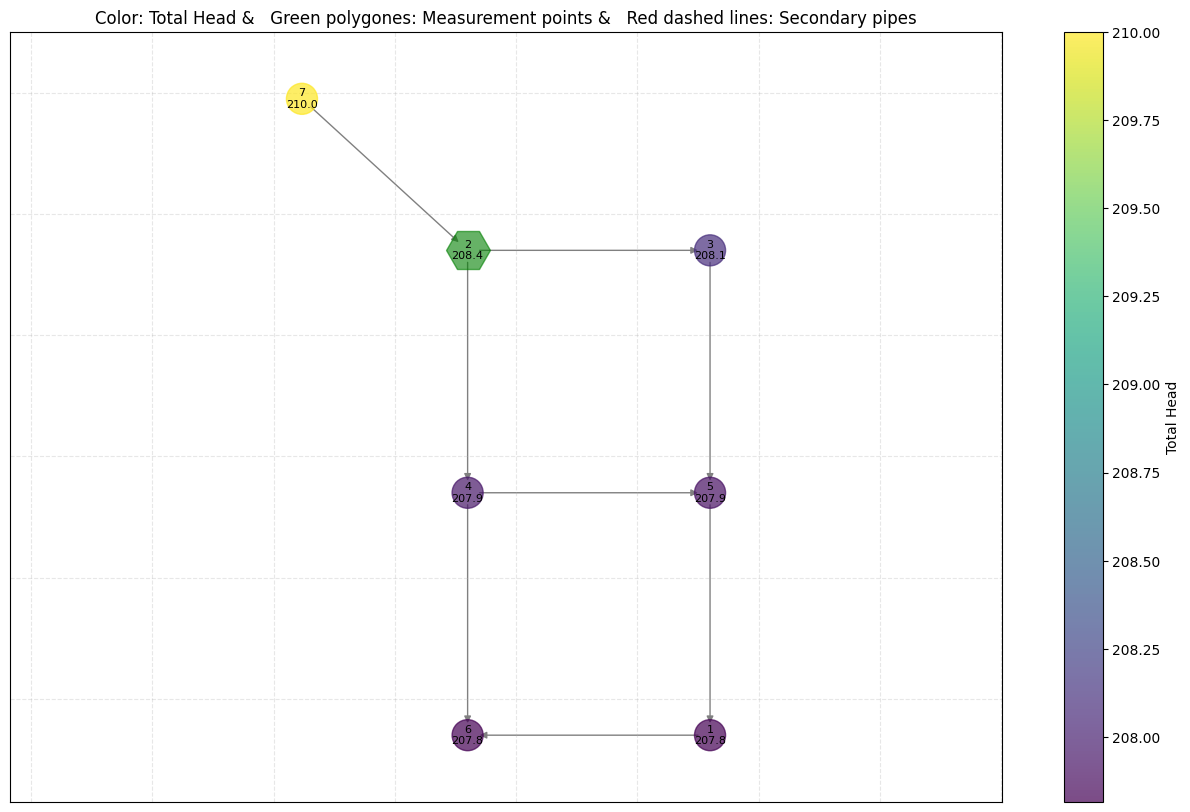

In [ ]:
# m = 1
#cmeasurement_nodes = select_measurement_points(wn, shortest_path_undirected, m)
#analyze_measurement_points(wn, shortest_path_undirected, measurement_nodes)
measurement_nodes = MEASUREMENT_NODES
# baghmalek ['3','70','24','48','14','57','42']
# Alperovit ['1','2']
# kadu ['3','14','19','24']
# hanoi ['2','12','25']
# anytown ['20','140']
# modena ['52', '79','89','94','150','28','55','244']
# Zhiiang ['110','16']

visualize_network_with_details(base_G, 
                             secondary_pipes=None,
                             measurement_nodes=measurement_nodes,
                             show_pressure=False, 
                             node_size_by_demand=False)
plt.show()

Original number of edges: 8
Number of edges after adding reverse edges: 10


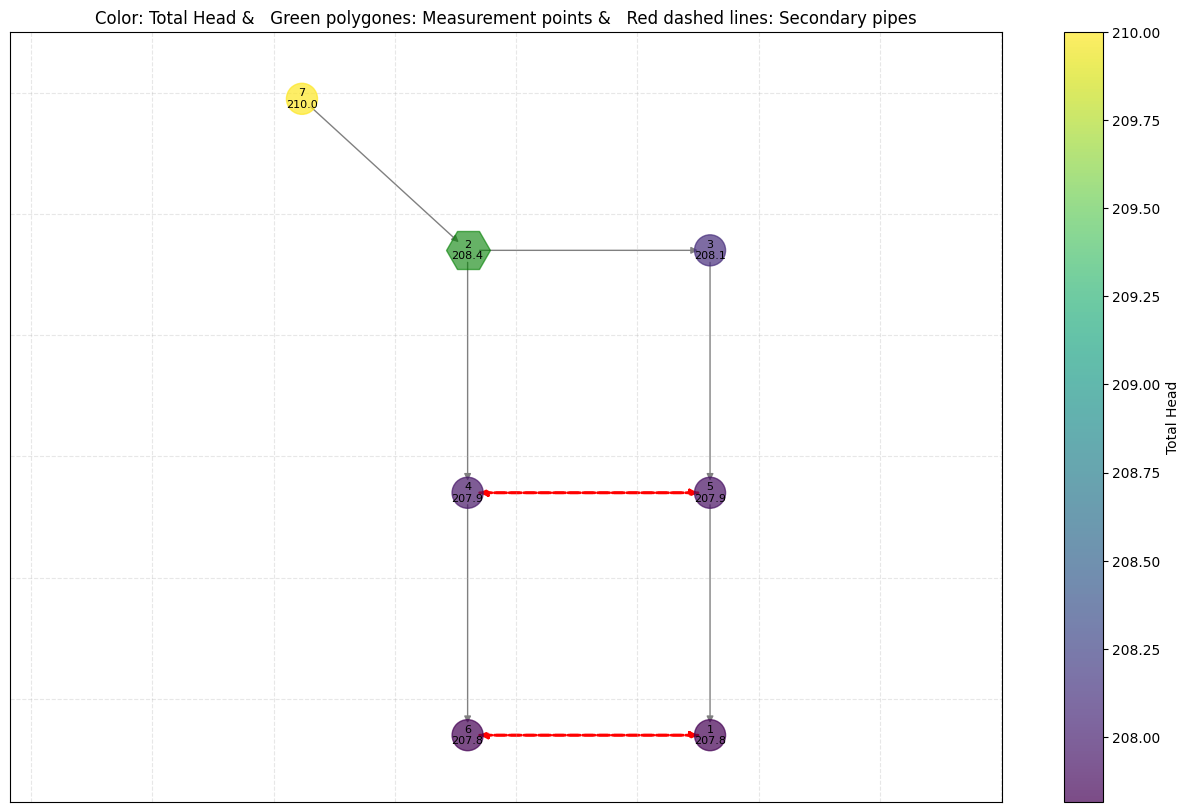

In [25]:
# Assuming you have G and secondary_pipes
G = base_G

G_with_reverse_edges = add_reverse_edges_for_secondary_pipes(G, secondary_pipes)


# Verify the changes
print("Original number of edges:", G.number_of_edges())
print("Number of edges after adding reverse edges:", G_with_reverse_edges.number_of_edges())

visualize_network_with_details(G_with_reverse_edges, 
                             secondary_pipes=secondary_pipes,
                             measurement_nodes=measurement_nodes,
                             show_pressure=False, 
                             node_size_by_demand=False)
plt.show()

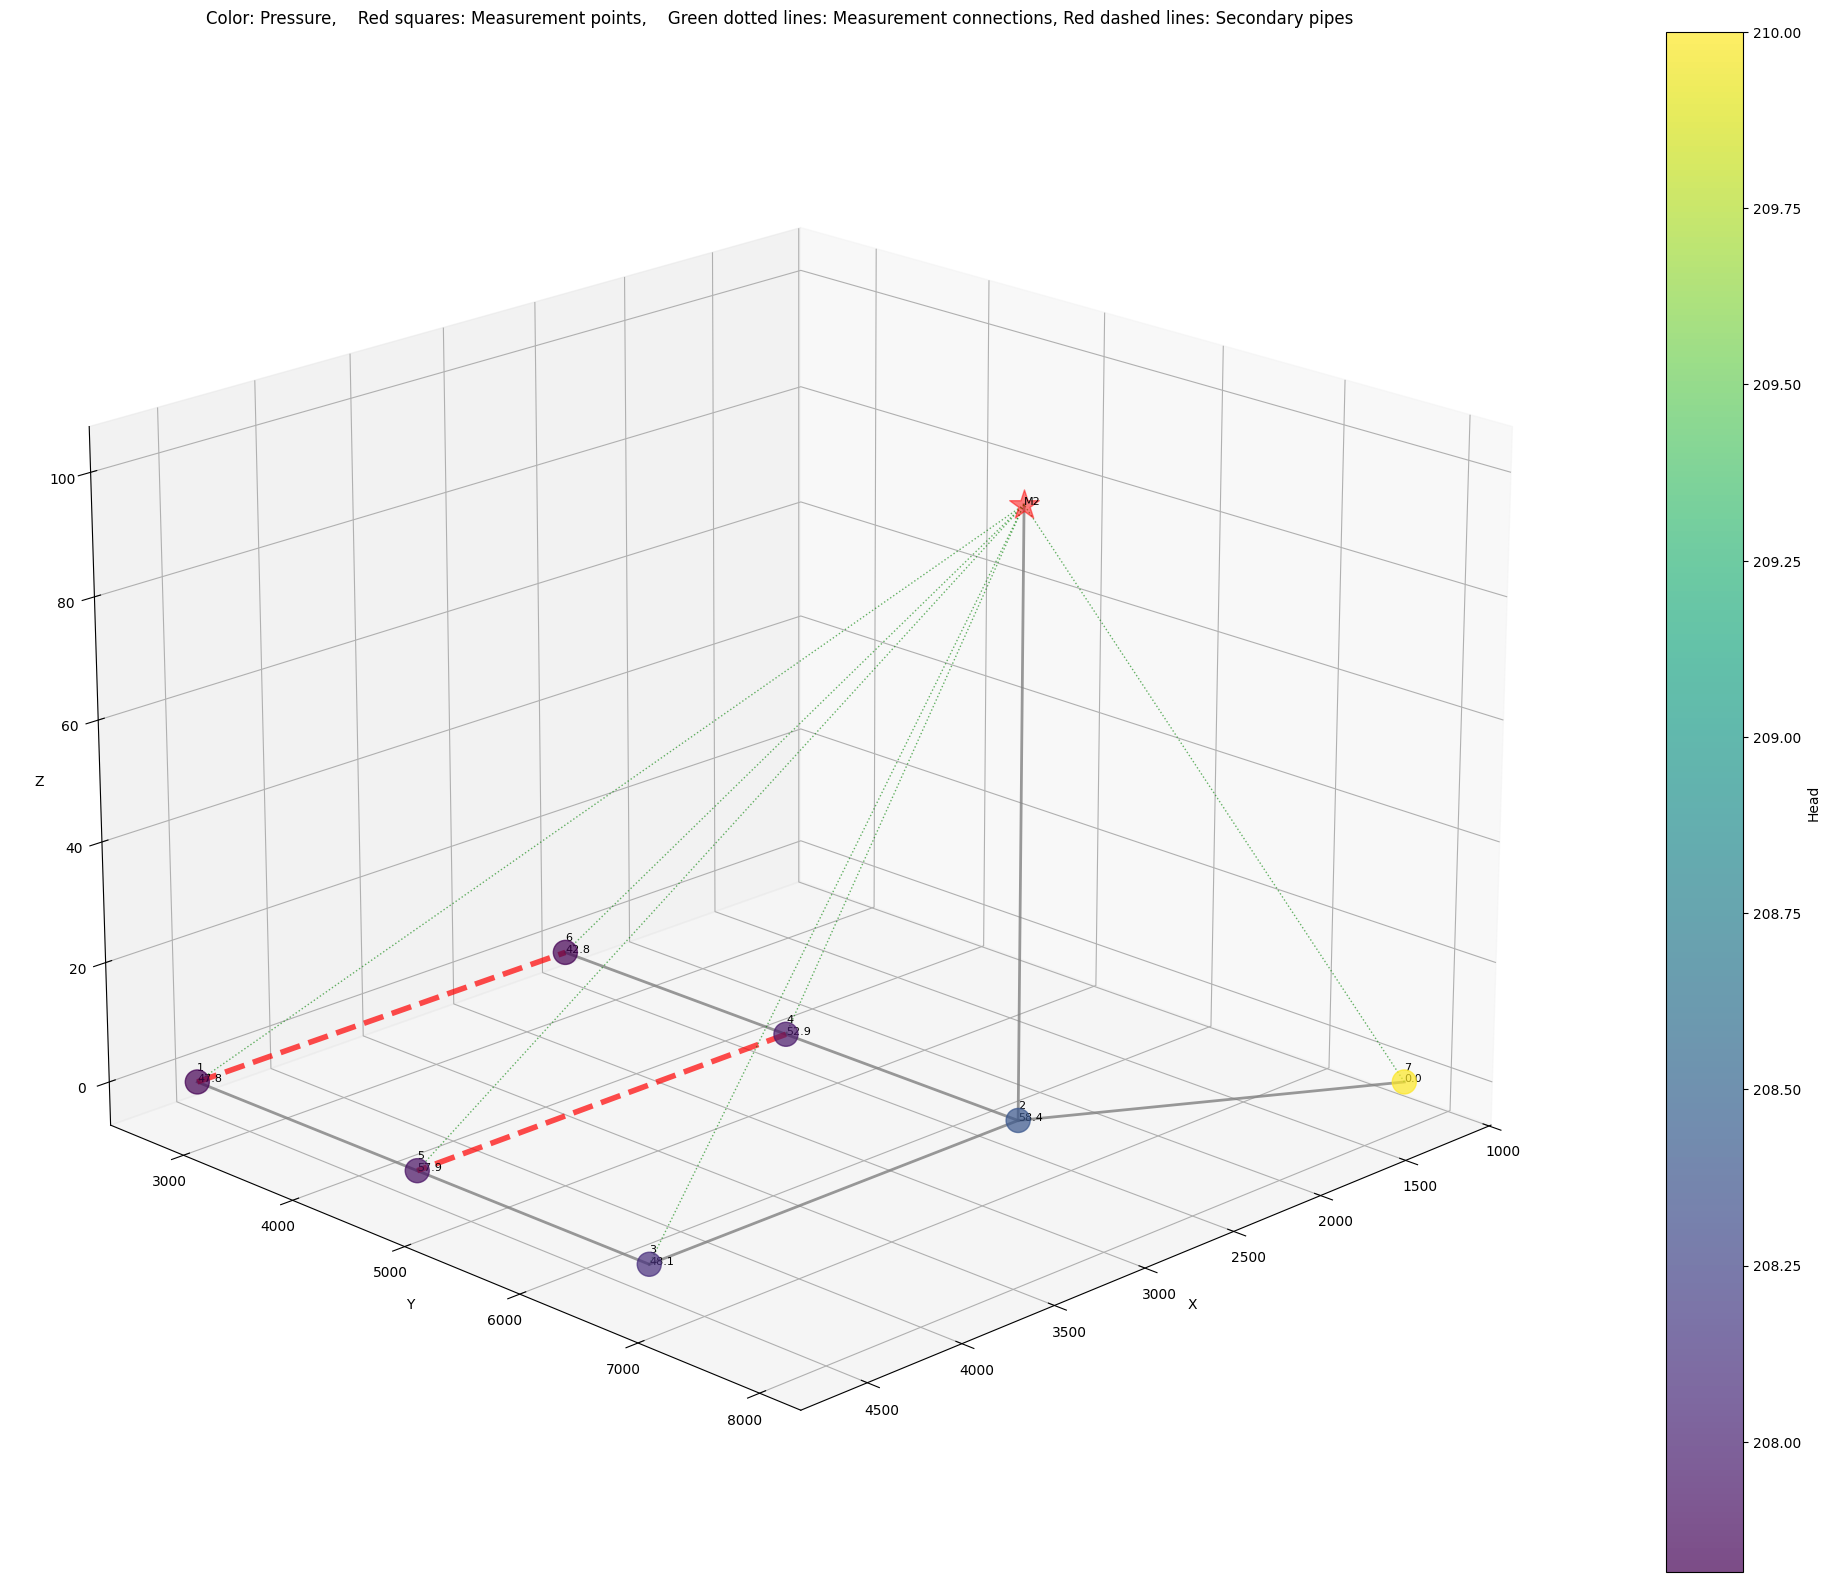

In [26]:
# Example usage:
# First compute base pressures and get the graph

G = compute_base_pressures_for_multipliers(wn,base_G, [1], [1])
G_with_measurements = add_measurement_points_to_graph(G, measurement_nodes, shortest_path)
# Visualize the network in 3D
# Example usage:
visualize_network_3d(G_with_measurements, 
                    secondary_pipes=secondary_pipes,
                    measurement_nodes=measurement_nodes,
                    show_pressure=False, 
                    node_size_by_demand=False)  # Set to True to show edge weights
plt.show()



In [27]:

# Example usage:
edge_index, edge_attr, edge_type, node_mapping = create_pyg_incidence_matrix(G_with_measurements)

# Print statistics
print_graph_statistics(G_with_measurements, edge_index, edge_attr, edge_type, node_mapping)

# Example of how to use the tensors
print("\nExample edge data:")
for i in range(min(5, edge_index.shape[1])):  # Print first 5 edges
    source_idx = edge_index[0, i].item()
    target_idx = edge_index[1, i].item()
    source_node = node_mapping[source_idx]
    target_node = node_mapping[target_idx]
    print(f"Edge {i}: {source_node} -> {target_node}")
    print(f"  Weight: {edge_attr[i].item():.3f}")
    print(f"  Type: {edge_type[i].item()}")


Graph Statistics:
Number of nodes: 8
Number of edges: 15
Number of measurement nodes: 1

PyG Format Statistics:
Edge index shape: torch.Size([2, 15])
Edge attr shape: torch.Size([15, 1])
Edge type shape: torch.Size([15, 1])

Edge type distribution:
Regular edges: 6
Secondary pipes: 2
Regular measurement connections: 6
Measurement self-connections: 1

Sample of node mapping (first 5 nodes):
Index 0: 2
Index 1: 3
Index 2: 4
Index 3: 5
Index 4: 6

Example edge data:
Edge 0: 2 -> 3
  Weight: 0.702
  Type: 0
Edge 1: 2 -> 4
  Weight: 0.681
  Type: 0
Edge 2: 3 -> 5
  Weight: 0.727
  Type: 0
Edge 3: 4 -> 5
  Weight: 0.818
  Type: 1
Edge 4: 4 -> 6
  Weight: 0.746
  Type: 0


In [28]:
def get_total_base_demand(wn):
    """
    Calculate the total base demand across all junctions in the network.
    
    Args:
        wn (wntr.network.WaterNetworkModel): The water network model
        
    Returns:
        float: Total base demand in the network
    """
    total_demand = 0
    for junction_name, junction in wn.junctions():
        total_demand += junction.base_demand
    return total_demand

def verify_uniform_distribution(num_simulations=5000, num_junctions=5, extra_demand=100):
    """
    Verify that the extra demand distribution is uniform across junctions over multiple simulations.
    
    Args:
        num_simulations (int): Number of simulations to run
        num_junctions (int): Number of junctions in the network
        extra_demand (float): Total extra demand to distribute
        
    Returns:
        dict: Statistics about the demand distribution
    """
    # Initialize counters
    total_demand_per_junction = np.zeros(num_junctions)
    zero_demand_counts = np.zeros(num_junctions)
    
    # Run simulations
    for _ in range(num_simulations):
        # Generate uniform distribution
        alpha = np.ones(num_junctions)
        probabilities = np.random.dirichlet(alpha)
        
        # Calculate demand for each junction
        demands = probabilities * extra_demand
        
        # Update statistics
        total_demand_per_junction += demands
        zero_demand_counts += (demands == 0)
    
    # Calculate statistics
    avg_demand_per_junction = total_demand_per_junction / num_simulations
    zero_demand_ratio = zero_demand_counts / num_simulations
    
    return {
        'average_demand_per_junction': avg_demand_per_junction,
        'zero_demand_ratio': zero_demand_ratio,
        'total_simulations': num_simulations
    }

def generate_synthetic_dataset(wn, num_simulations=5000, extra_demand=100):
    """
    Generate a synthetic dataset by adding uniformly distributed extra demand to the water network.
    
    Args:
        wn (wntr.network.WaterNetworkModel): The water network model
        num_simulations (int): Number of simulations to run
        extra_demand (float): Total extra demand to distribute
        
    Returns:
        list: List of dictionaries containing simulation results
    """
    from steady_data_generator import add_uniform_extra_demand
    
    dataset = []
    for i in range(num_simulations):
        # Add uniformly distributed extra demand
        wn_mod, demand_distribution = add_uniform_extra_demand(wn, extra_demand)
        
        # Run hydraulic simulation
        sim = wntr.sim.EpanetSimulator(wn_mod)
        results = sim.run_sim()
        
        # Store results
        dataset.append({
            'demand_distribution': demand_distribution,
            'pressures': results.node['pressure'].iloc[-1],
            'flows': results.link['flowrate'].iloc[-1]
        })
        
        # Print progress every 10%
        if (i + 1) % (num_simulations // 10) == 0:
            print(f"Progress: {i + 1}/{num_simulations} simulations completed")
    
    return dataset 

def add_uniform_extra_demand(wn, extra_demand=1):
    """
    Add extra demand to junctions using a uniform probability distribution.
    The extra demand is distributed among junctions such that each junction has an equal
    chance of receiving any portion of the total extra demand.
    
    Args:
        wn (wntr.network.WaterNetworkModel): The water network model
        extra_demand (float): Total amount of extra demand to distribute (default: 1)
        
    Returns:
        tuple: (modified wn, demand_distribution)
            - modified wn: Water network with extra demand added
            - demand_distribution: Dictionary mapping junction names to their extra demand values
    """
    # Create a deep copy to avoid modifying the original network
    wn_copy = copy.deepcopy(wn)
    
    # Get all junctions
    junctions = [name for name, junction in wn_copy.junctions()]
    num_junctions = len(junctions)
    
    if num_junctions == 0:
        return wn_copy, {}
    
    # Generate uniform random numbers for each junction
    # We use Dirichlet distribution to ensure sum = 1
    # Alpha = 1 for uniform distribution
    alpha = np.ones(num_junctions)
    probabilities = np.random.dirichlet(alpha)
    
    # Create demand distribution dictionary
    demand_distribution = {}
    
    # Add extra demand to each junction based on probabilities
    for junction_name, prob in zip(junctions, probabilities):
        junction = wn_copy.get_node(junction_name)
        
        # Calculate extra demand for this junction
        junction_extra_demand = prob * extra_demand
        
        # Add to base demand if it exists
        if junction.demand_timeseries_list:
            current_base_demand = junction.demand_timeseries_list[0].base_value
            junction.demand_timeseries_list[0].base_value = current_base_demand + junction_extra_demand
        
        # Store the distribution
        demand_distribution[junction_name] = junction_extra_demand
    
    return wn_copy, demand_distribution    

def generate_training_data(wn, min_elv, pressure_threshold=0, min_deviation=0, max_deviation=3):
    """
    Generate a training data sample by adding uniformly distributed extra demand to the network.
    
    The extra demand is calculated as: random_number * total_base_demand
    where random_number is drawn from a uniform distribution between min_deviation and max_deviation.
    
    After adding the extra demand, the network is simulated using WNTR's EpanetSimulator.
    The final node pressures are extracted from the simulation. If any node that is not a 
    reservoir records a pressure below the provided threshold, the function returns None.
    
    Args:
        wn (wntr.network.WaterNetworkModel): The base water network model.
        pressure_threshold (float): Minimum acceptable pressure for any non-reservoir node.
        min_deviation (float): Minimum deviation factor for extra demand (default: 0).
        max_deviation (float): Maximum deviation factor for extra demand (default: 1).
    
    Returns:
        tuple or None: A tuple containing (pressures, has_leakage, leakage_nodes) if all non-reservoir 
                      nodes have pressures above the threshold; otherwise, None.
    """
    # Create a deep copy of the network to avoid modifying the original model
    wn_mod = copy.deepcopy(wn)
    
    
    # Calculate total base demand
    total_base_demand = get_total_base_demand(wn)
    
    # Generate random deviation factor
    deviation_factor = np.random.uniform(min_deviation, max_deviation)
    
    # Calculate extra demand
    extra_demand = deviation_factor * total_base_demand
    
    # Add uniformly distributed extra demand
    wn_mod, demand_distribution = add_uniform_extra_demand(wn_mod, extra_demand)
    
    # Run a hydraulic simulation on the modified network
    sim = wntr.sim.EpanetSimulator(wn_mod)
    results = sim.run_sim()
    
    # Extract pressures and heads from the final simulation time step
    pressures_series = results.node['pressure'].iloc[-1]
    heads_series = results.node['head'].iloc[-1]
    
    # Get reservoir nodes
    reservoir_nodes = get_reservoir_nodes(wn)
    if not reservoir_nodes:
        raise ValueError("No reservoir found in the water network model")
    reservoir_node = reservoir_nodes[0]
    
    # Create the final pressure dictionary, using head for reservoirs
    pressures = {}
    for node, p in pressures_series.items():
        if node in reservoir_node:
            pressures[node] = heads_series[node] - min_elv # Use fixed head for reservoirs
        else:
            pressures[node] = p
    
    # Check that every non-reservoir node meets the pressure threshold
    for node, p in pressures.items():
        if node not in reservoir_node and p < pressure_threshold:
            return None
    
    # Return the simulated pressure values
    # Note: has_leakage and leakage_nodes are set to False and empty set since we're not using leakages anymore
    return pressures, demand_distribution, False, set()



def analyze_dataset(dataset, stats):
    """
    Analyze the generated dataset to verify its properties.
    """
    print("\nDataset Generation Summary:")
    print(f"Reservoir node: {stats['reservoir_node']}")
    print(f"Reservoir head: {stats['reservoir_head']:.2f}")
    print(f"Number of measurement nodes: {len(stats['measurement_nodes'])}")
    
    # Get feature vector length from first simulation
    feature_length = dataset[0]['x'].shape[1]
    print(f"\nFeature vector length: {feature_length}")
    print(f"  Base pressure components: {feature_length - 1}")
    print(f"  Additional value: 1")
    
    print(f"\nSimulation Statistics:")
    print(f"Total attempted: {stats['total_simulations']}")
    print(f"Accepted: {stats['accepted_simulations']}")
    print(f"Rejected: {stats['rejected_simulations']}")
    
    print(f"\nRejection reasons:")
    print(f"  Negative pressure: {stats['rejection_reasons']['negative_pressure']}")
    print(f"  Below minimum pressure: {stats['rejection_reasons']['below_min_pressure']}")
    
    print(f"\nLeakage Statistics:")
    print(f"Total scenarios with leakage: {stats['leakage_stats']['total_leakages']}")
    print(f"Number of unique leakage nodes: {len(stats['leakage_stats']['leakage_nodes'])}")
    print(f"Leakage nodes: {sorted(list(stats['leakage_stats']['leakage_nodes']))}")
    
    # Analyze feature vectors
    x_all = torch.cat([data['x'] for data in dataset])
    y_all = torch.cat([data['y'] for data in dataset])
    
    print(f"\nFeature Statistics:")
    print(f"Base pressure components (first {feature_length-1}):")
    for i in range(feature_length-1):
        values = x_all[:, i]
        print(f"  Component {i+1}: Min={values.min():.4f}, Max={values.max():.4f}, Mean={values.mean():.4f}")
    print(f"Additional value (last component):")
    values = x_all[:, -1]
    print(f"  Min={values.min():.4f}, Max={values.max():.4f}, Mean={values.mean():.4f}")
    
    print(f"\nLabel Statistics:")
    print(f"  Min: {y_all.min():.4f}")
    print(f"  Max: {y_all.max():.4f}")
    print(f"  Mean: {y_all.mean():.4f}")
    print(f"  Std: {y_all.std():.4f}")

In [29]:
def generate_gnn_dataset(G, wn, n_simulations,min_p, max_p, min_elv, min_allowable_pressure=0.0, 
                        min_deviation=0, max_deviation=1, add_noise=False, noise_std=0.01):
    """
    Generate dataset for GNN training with multiple hydraulic simulations.
    
    Args:
        G (networkx.Graph): The water network graph
        wn (wntr.network.WaterNetworkModel): The water network model
        n_simulations (int): Number of simulations to run
        min_allowable_pressure (float): Minimum acceptable pressure for any non-reservoir node
        min_deviation (float): Minimum deviation factor for extra demand
        max_deviation (float): Maximum deviation factor for extra demand
        add_noise (bool): Whether to add noise to measurement node pressures
        noise_std (float): Standard deviation of the noise if add_noise is True
        
    Returns:
        tuple: (dataset, stats)
            - dataset: List of dictionaries containing simulation data
            - stats: Dictionary containing statistics about the dataset generation
    """
    # Initialize statistics dictionary
    stats = {
        'total_simulations': n_simulations,
        'accepted_simulations': 0,
        'rejected_simulations': 0,
        'rejection_reasons': {
            'negative_pressure': 0,
            'below_min_pressure': 0
        }
    }
    
    # Get network information
    reservoir_nodes = get_reservoir_nodes(wn)
    if not reservoir_nodes:
        raise ValueError("No reservoir found in the water network model")
    reservoir_node = reservoir_nodes[0]
    
    # Get measurement points and create mapping to physical nodes
    measurement_nodes = [node for node in G.nodes() if str(node).startswith('meas_')]
    measurement_to_physical = {
        meas_node: str(meas_node).split('_')[1] 
        for meas_node in measurement_nodes
    }
    print(f"Found {len(measurement_nodes)} measurement nodes")
    
    # Get reservoir head for normalization
    reservoir_attrs = G.nodes[reservoir_node]
    reservoir_head = reservoir_attrs['head'][0]
    print(f"Using reservoir node: {reservoir_node} with head: {reservoir_head}")
    
    # Create edge information (this remains constant across simulations)
    edge_index, edge_attr, edge_type, node_mapping = create_pyg_incidence_matrix(G)
    
    # Create reverse mapping from node names to indices
    idx_to_node = {idx: node for idx, node in enumerate(G.nodes())}
    
    # Precompute shortest paths from each node to all measurement points
    print("Precomputing shortest paths...")
    shortest_paths = {}
    for node in G.nodes():
        if not str(node).startswith('meas_'):  # Skip measurement nodes
            paths = {}
            for meas_node in measurement_nodes:
                try:
                    # Try path from node to measurement
                    path_length = nx.shortest_path_length(G, source=node, target=meas_node, weight='weight')
                    paths[meas_node] = path_length
                except nx.NetworkXNoPath:
                    try:
                        # Try path from measurement to node
                        path_length = nx.shortest_path_length(G, source=meas_node, target=node, weight='weight')
                        paths[meas_node] = path_length
                    except:
                        # No path exists between these nodes in either direction
                        continue
            if paths:  # Only store if we found at least one path
                shortest_paths[node] = paths
    
    # Store all simulation results
    dataset = []
    sim_count = 0
    
    while sim_count < n_simulations:
        # Generate new pressure values
        result = generate_training_data(
            wn,
            min_elv=min_elv,
            pressure_threshold=min_allowable_pressure,
            min_deviation=min_deviation,
            max_deviation=max_deviation
        )
        
        if result is None:
            stats['rejected_simulations'] += 1
            continue
            
        simulated_pressures, demand_distribution, _, _ = result
        
        # Validate pressures
        if not validate_pressures(simulated_pressures, min_allowable_pressure, stats):
            stats['rejected_simulations'] += 1
            continue

        # Create feature vectors and labels
        x_features, y, node_types, node_masks = create_node_features(
            G=G,
            idx_to_node=idx_to_node,
            measurement_nodes=measurement_nodes,
            measurement_to_physical=measurement_to_physical,
            shortest_paths=shortest_paths,
            simulated_pressures=simulated_pressures,
            add_noise=add_noise,
            noise_std=noise_std,
            min_p=min_p,
            max_p=max_p
        )
        
        # Convert to tensors
        x = torch.tensor(x_features, dtype=torch.float)
        y = torch.tensor(y, dtype=torch.float).reshape(-1, 1)
        node_types = torch.tensor(node_types, dtype=torch.int)
        node_masks = torch.tensor(node_masks, dtype=torch.bool)
        
        # Capture demands for this simulation
        junction_names = [
            n for n in G.nodes()
            if not str(n).startswith('meas_')
            and G.nodes[n].get('node_type', '').lower() != 'reservoir'
        ]
        d_values = [demand_distribution.get(str(n), 0.0) for n in junction_names]

        # Create data dictionary for this simulation
        data_dict = {
            'edge_index': edge_index,
            'edge_attr': edge_attr,
            'edge_type': edge_type,
            'x': x,
            'y': y,
            'node_type': node_types,
            'mask': node_masks,
            'node_mapping': node_mapping,
            'reservoir_head': reservoir_head,
            'simulation_id': sim_count,
            'feature_vector_length': x.shape[1],
            'd': torch.tensor(d_values, dtype=torch.float),
            'junction_names': junction_names
        }
        
        dataset.append(data_dict)
        stats['accepted_simulations'] += 1
        sim_count += 1
        
        # Print progress every 10%
        if sim_count % (n_simulations // 10) == 0:
            print(f"Progress: {sim_count}/{n_simulations} simulations completed")
    
    # Add final statistics
    stats.update({
        'reservoir_node': reservoir_node,
        'reservoir_head': reservoir_head,
        'min_p':min_p,
        'max_p':max_p,
        'measurement_nodes': measurement_nodes,
        'node_mapping': node_mapping,
        'demand_stats': {
            'min_deviation': min_deviation,
            'max_deviation': max_deviation,
            'total_demand': get_total_base_demand(wn)
        }
    })
    
    return dataset, stats

def validate_pressures(simulated_pressures, min_allowable_pressure, stats):
    """
    Validate the simulated pressures.
    
    Args:
        simulated_pressures (dict): Dictionary of node pressures
        min_allowable_pressure (float): Minimum acceptable pressure
        stats (dict): Statistics dictionary to update
        
    Returns:
        bool: True if pressures are valid, False otherwise
    """
    for node, pressure in simulated_pressures.items():
        if pressure < 0:
            stats['rejection_reasons']['negative_pressure'] += 1
            return False
        elif pressure < min_allowable_pressure:
            stats['rejection_reasons']['below_min_pressure'] += 1
            return False
    return True

def create_node_features(G, idx_to_node, measurement_nodes, measurement_to_physical,
                        shortest_paths, simulated_pressures,
                        add_noise, noise_std, min_p, max_p):
    """
    Create feature vectors and labels for all nodes.
    
    Args:
        G (networkx.Graph): The water network graph
        idx_to_node (dict): Mapping from indices to node names
        measurement_nodes (list): List of measurement nodes
        measurement_to_physical (dict): Mapping from measurement nodes to physical nodes
        shortest_paths (dict): Precomputed shortest paths
        simulated_pressures (dict): Simulated pressures for all nodes
        base_pressure_vector (list): Base pressure vector
        add_noise (bool): Whether to add noise
        noise_std (float): Standard deviation of noise
        
    Returns:
        tuple: (x_features, y, node_types, node_masks)
    """
    x_features = []
    y = []
    node_types = []
    node_masks = []
    
    for node_idx in range(len(G.nodes())):
        node = idx_to_node[node_idx]
        node_data = G.nodes[node]
        
        # Determine node type and create mask
        node_type, node_mask = determine_node_type(node_data)
        node_types.append(node_type)
        node_masks.append(node_mask)
        
        # Get base pressure vector
        base_pressure_vector = node_data.get('base_pressure', [0.0])
        base_pressure_vector = [(p-min_p) / (max_p-min_p) for p in base_pressure_vector]  # Normalize
        
        # Calculate additional value based on node type
        if node in measurement_nodes:
            additional_value = get_measurement_node_value(
                node, measurement_to_physical, simulated_pressures, add_noise, noise_std
            )
        else:
            additional_value = get_regular_node_value(
                node, shortest_paths, measurement_to_physical, simulated_pressures, base_pressure_vector
            )
        
        # Combine features
        node_features = base_pressure_vector + [additional_value, node_type]
        x_features.append(node_features)
        
        # Get label (pressure)
        pressure = get_node_pressure(node, measurement_nodes, measurement_to_physical, simulated_pressures)
        y.append((pressure-min_p) / (max_p-min_p))  # Normalize
    
    return x_features, y, node_types, node_masks

def determine_node_type(node_data):
    """
    Determine the type and mask for a node.
    
    Args:
        node_data (dict): Node attributes
        
    Returns:
        tuple: (node_type, node_mask)
    """
    node_type_str = node_data.get('node_type', '').lower()
    if node_type_str == 'reservoir':
        return 2, True  # Reservoir
    elif node_type_str == 'measurement':
        return 1, True  # Measurement
    elif node_type_str == 'junction':
        return 0, False  # Junction
    else:
        return 3, True  # Other

def get_measurement_node_value(node, measurement_to_physical, simulated_pressures, add_noise, noise_std):
    """
    Get the additional value for a measurement node.
    
    Args:
        node (str): Node name
        measurement_to_physical (dict): Mapping from measurement nodes to physical nodes
        simulated_pressures (dict): Simulated pressures
        add_noise (bool): Whether to add noise
        noise_std (float): Standard deviation of noise
        
    Returns:
        float: Additional value
    """
    physical_node = measurement_to_physical[node]
    simulated_pressure = simulated_pressures[physical_node]
    additional_value = (simulated_pressure-min_p) / (max_p-min_p)
    if add_noise:
        additional_value += np.random.normal(0, noise_std)
    return additional_value

def get_regular_node_value(node, shortest_paths, measurement_to_physical, simulated_pressures, G):
    """
    Get the additional value for a regular node.
    
    Args:
        node (str): Node name
        shortest_paths (dict): Precomputed shortest paths
        measurement_to_physical (dict): Mapping from measurement nodes to physical nodes
        simulated_pressures (dict): Simulated pressures
        G (networkx.Graph): The water network graph
        
    Returns:
        float: Additional value
    """
    connected_measurements = []
    weights = []
    
    if node in shortest_paths:
        for meas_node, path_length in shortest_paths[node].items():
            weight = 1.0 / (path_length + 1e-6)
            physical_node = measurement_to_physical[meas_node]
            connected_measurements.append(simulated_pressures[physical_node])
            weights.append(weight)
    
    if connected_measurements:
        weights = np.array(weights)
        weights = weights / weights.sum()
        weighted_pressures = np.array(connected_measurements)
        additional_value = np.sum(weights * weighted_pressures)
        return (additional_value-min_p) / (max_p-min_p)
    else:
        # If no measurement connections, use mean of base pressure vector
        base_pressure_vector = G.nodes[node].get('base_pressure', [0.0])
        base_pressure_vector = [(p-min_p) / (max_p-min_p) for p in base_pressure_vector]  # Normalize
        return np.mean(base_pressure_vector)


def get_node_pressure(node, measurement_nodes, measurement_to_physical, simulated_pressures):
    """
    Get the pressure value for a node.
    
    Args:
        node (str): Node name
        measurement_nodes (list): List of measurement nodes
        measurement_to_physical (dict): Mapping from measurement nodes to physical nodes
        simulated_pressures (dict): Simulated pressures
        
    Returns:
        float: Pressure value
    """
    if node in measurement_nodes:
        physical_node = measurement_to_physical[node]
        return simulated_pressures[physical_node]
    else:
        return simulated_pressures[node]

In [30]:
# Generate dataset
dataset, stats = generate_gnn_dataset(
    G_with_measurements,  # Your networkx graph
    wn,  # Your water network model
    min_elv=get_max_elevation(wn),
    n_simulations=5000,
    min_p=min_p,
    max_p=max_p,
    min_allowable_pressure=0.0,
    min_deviation=0,  # Minimum extra demand factor
    max_deviation=1,# Maximum extra demand factor
    add_noise=False,  # Add noise to measurement nodes
    noise_std=0   # Standard deviation of noise
)

# Print statistics
print(f"Total simulations: {stats['total_simulations']}")
print(f"Accepted simulations: {stats['accepted_simulations']}")
print(f"Rejected simulations: {stats['rejected_simulations']}")
print(f"Total base demand: {stats['demand_stats']['total_demand']}")

Found 1 measurement nodes
Using reservoir node: 7 with head: 210.0
Precomputing shortest paths...
Progress: 500/5000 simulations completed
Progress: 1000/5000 simulations completed
Progress: 1500/5000 simulations completed
Progress: 2000/5000 simulations completed
Progress: 2500/5000 simulations completed
Progress: 3000/5000 simulations completed
Progress: 3500/5000 simulations completed
Progress: 4000/5000 simulations completed
Progress: 4500/5000 simulations completed
Progress: 5000/5000 simulations completed
Total simulations: 5000
Accepted simulations: 5000
Rejected simulations: 0
Total base demand: 1.12


In [ ]:
def save_dataset_splits(dataset, stats, base_dir, seed=42, test_size=0.2, val_size=0.2):
    """
    Save train/val/test splits and stats to fixed files in base_dir.
    """
    import json
    import os
    import torch
    from sklearn.model_selection import train_test_split
    from torch_geometric.data import Data
    
    os.makedirs(base_dir, exist_ok=True)
    
    def create_pyg_data(simulation_data):
        return Data(
            x=simulation_data['x'],
            edge_index=simulation_data['edge_index'],
            edge_attr=simulation_data['edge_attr'],
            y=simulation_data['y'],
            edge_type=simulation_data['edge_type'],
            mask=simulation_data['mask'],
            d=simulation_data.get('d'),
            junction_names=simulation_data.get('junction_names')
        )
    
    pyg_dataset = [create_pyg_data(sim_data) for sim_data in dataset]
    
    train_data, test_data = train_test_split(pyg_dataset, test_size=test_size, random_state=seed)
    train_data, val_data = train_test_split(train_data, test_size=val_size, random_state=seed)
    
    train_path = os.path.join(base_dir, "train_dataset.pt")
    val_path = os.path.join(base_dir, "val_dataset.pt")
    test_path = os.path.join(base_dir, "test_dataset.pt")
    stats_path = os.path.join(base_dir, "dataset_stats.json")
    metadata_path = os.path.join(base_dir, "dataset_metadata.json")
    
    torch.save(train_data, train_path)
    torch.save(val_data, val_path)
    torch.save(test_data, test_path)
    
    serializable_stats = {}
    for key, value in stats.items():
        if isinstance(value, (list, dict, str, int, float, bool)):
            if key == 'leakage_stats' and isinstance(value, dict):
                serializable_stats[key] = {
                    'total_leakages': value.get('total_leakages', 0),
                    'leakage_nodes': list(value.get('leakage_nodes', []))
                }
            else:
                serializable_stats[key] = value
        else:
            serializable_stats[key] = str(value)
    
    with open(stats_path, 'w') as f:
        json.dump(serializable_stats, f, indent=4)
    
    metadata = {
        'wdn_name': WDN_NAME,
        'num_simulations': len(dataset),
        'num_nodes': dataset[0]['x'].shape[0] if dataset else 0,
        'feature_vector_length': dataset[0]['x'].shape[1] if dataset else 0,
        'num_edges': dataset[0]['edge_index'].shape[1] if dataset else 0,
        'train_size': len(train_data),
        'val_size': len(val_data),
        'test_size': len(test_data),
        'seed': seed,
        'split_test_size': test_size,
        'split_val_size': val_size,
        'train_dataset_path': train_path,
        'val_dataset_path': val_path,
        'test_dataset_path': test_path,
        'stats_path': stats_path
    }
    
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=4)
    
    print(f"Train dataset saved to: {train_path}")
    print(f"Validation dataset saved to: {val_path}")
    print(f"Test dataset saved to: {test_path}")
    print(f"Stats saved to: {stats_path}")
    print(f"Metadata saved to: {metadata_path}")
    
    return train_path, val_path, test_path, stats_path, metadata_path
    

def save_evaluation_artifacts(base_dir, G_with_measurements, secondary_pipes, measurement_nodes, node_mapping, reservoir_nodes):
    import json
    import os
    import pickle
    
    os.makedirs(base_dir, exist_ok=True)
    graph_path = os.path.join(base_dir, "graph_with_measurements.pickle")
    with open(graph_path, "wb") as f:
        pickle.dump(G_with_measurements, f)
    
    artifacts = {
        "secondary_pipes": list(secondary_pipes) if secondary_pipes else [],
        "measurement_nodes": [str(n) for n in (measurement_nodes or [])],
        "reservoir_nodes": [str(n) for n in (reservoir_nodes or [])],
        "node_mapping": {str(k): str(v) for k, v in (node_mapping or {}).items()},
        "node_list": [str(n) for n in G_with_measurements.nodes()]
    }
    metadata_path = os.path.join(base_dir, "evaluation_artifacts.json")
    with open(metadata_path, "w") as f:
        json.dump(artifacts, f, indent=4)
    
    print(f"Saved graph to: {graph_path}")
    print(f"Saved evaluation artifacts to: {metadata_path}")
    
    return graph_path, metadata_path
    

import os
output_dir = os.path.join(BASE_DIR, "data_generator")
save_dataset_splits(dataset, stats, output_dir)
reservoir_nodes = get_reservoir_nodes(wn)
save_evaluation_artifacts(output_dir, G_with_measurements, secondary_pipes, measurement_nodes, node_mapping, reservoir_nodes)

Dataset saved to: data/water_network_dataset_20260317_125111_dataset.pt
Stats saved to: data/water_network_dataset_20260317_125111_stats.json
Metadata saved to: data/water_network_dataset_20260317_125111_metadata.json

Dataset Verification:
Number of simulations: 5000
Feature dimensions: torch.Size([8, 3])
Edge index dimensions: torch.Size([2, 15])

Stats Verification:
Total simulations: 5000
Accepted simulations: 5000

Metadata Verification:
Timestamp: 20260317_125111
Number of nodes: 8
Feature vector length: 3
Number of edges: 15
